# Overview of the ML-OPF Research Landscape

This notebook characterizes the broader academic ML-OPF literature
retrieved from Scopus before the application of patent- and policy-citation
filters.

The full Scopus corpus provides the academic baseline against which the
patent-cited and policy-cited subsets are subsequently interpreted.

The analysis covers:

1. publication growth;
2. leading publication sources;
3. leading authors;
4. geographic distribution of the literature; and
5. the principal academic research themes.

In [5]:
from pathlib import Path
import platform
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = NOTEBOOK_DIR


DATA_DIR = (
    PROJECT_DIR
    / "data"
)

SCOPUS_DIR = (
    DATA_DIR
    / "scopus"
)

LDA_DATA_DIR = (
    DATA_DIR
    / "lda"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "output"
)

LANDSCAPE_DIR = (
    OUTPUT_DIR
    / "scopus_research_landscape"
)

TABLE_DIR = (
    LANDSCAPE_DIR
    / "tables"
)

FIGURE_DIR = (
    LANDSCAPE_DIR
    / "figures"
)

ACADEMIC_LDA_DIR = (
    LANDSCAPE_DIR
    / "lda"
)


for directory in [
    LANDSCAPE_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    ACADEMIC_LDA_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


SCOPUS_FILE = (
    SCOPUS_DIR
    / "scopus_full.xlsx"
)


print("Project directory :", PROJECT_DIR)
print("Scopus file       :", SCOPUS_FILE)
print("Output directory  :", LANDSCAPE_DIR)

Project directory : /nfs/mfirdausi/project/review_paper_fahruddin
Scopus file       : /nfs/mfirdausi/project/review_paper_fahruddin/data/scopus/scopus_full.xlsx
Output directory  : /nfs/mfirdausi/project/review_paper_fahruddin/output/scopus_research_landscape


## 1. Load and Validate Scopus Data

The complete Scopus dataset is loaded as the academic baseline for the
research-landscape analysis. No patent- or policy-citation filter is applied
at this stage.

In [6]:
# ---------------------------------------------------------
# Load Scopus academic baseline
# ---------------------------------------------------------

scopus = pd.read_excel(
    SCOPUS_FILE
)


# ---------------------------------------------------------
# Validate required source columns
# ---------------------------------------------------------

REQUIRED_COLUMNS = [
    "Title",
    "Year",
    "DOI",
    "Abstract",
]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in scopus.columns
]

if missing_columns:
    raise ValueError(
        "Missing required Scopus columns: "
        + ", ".join(missing_columns)
    )


# ---------------------------------------------------------
# Standardized title
# ---------------------------------------------------------

scopus["Title_clean"] = (
    scopus["Title"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# ---------------------------------------------------------
# Standardized abstract
# ---------------------------------------------------------

scopus["Abstract_clean"] = (
    scopus["Abstract"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# ---------------------------------------------------------
# Standardized publication year
# ---------------------------------------------------------

scopus["Year_clean"] = pd.to_numeric(
    scopus["Year"],
    errors="coerce",
)


# ---------------------------------------------------------
# Standardized DOI
#
# Literal 0 in the Scopus file denotes unavailable DOI.
# ---------------------------------------------------------

doi_raw = (
    scopus["DOI"]
    .fillna("")
    .astype(str)
    .str.strip()
)

invalid_doi = (
    doi_raw.eq("")
    | doi_raw.eq("0")
    | doi_raw.str.lower().isin(
        [
            "nan",
            "none",
            "null",
        ]
    )
)

scopus["DOI_clean"] = (
    doi_raw
    .mask(
        invalid_doi
    )
    .str.lower()
    .str.replace(
        r"^https?://(dx\.)?doi\.org/",
        "",
        regex=True,
    )
    .str.replace(
        r"^doi:\s*",
        "",
        regex=True,
    )
    .str.strip()
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

print("SCOPUS ACADEMIC BASELINE")
print("=" * 50)

print(
    "Documents             :",
    f"{len(scopus):,}"
)

print(
    "Non-empty titles      :",
    f"{scopus['Title_clean'].ne('').sum():,}"
)

print(
    "Non-empty abstracts   :",
    f"{scopus['Abstract_clean'].ne('').sum():,}"
)

print(
    "Valid publication year:",
    f"{scopus['Year_clean'].notna().sum():,}"
)

print(
    "Valid DOI             :",
    f"{scopus['DOI_clean'].notna().sum():,}"
)

print(
    "Missing DOI           :",
    f"{scopus['DOI_clean'].isna().sum():,}"
)

print(
    "Unique valid DOI      :",
    f"{scopus['DOI_clean'].nunique():,}"
)

print()

print(
    "Year range            :",
    f"{int(scopus['Year_clean'].min())}-"
    f"{int(scopus['Year_clean'].max())}"
)

SCOPUS ACADEMIC BASELINE
Documents             : 50,761
Non-empty titles      : 50,761
Non-empty abstracts   : 50,761
Valid publication year: 50,761
Valid DOI             : 50,761
Missing DOI           : 0
Unique valid DOI      : 50,761

Year range            : 2000-2027


In [7]:
PATENT_FILE = (
    LDA_DATA_DIR
    / "lens_from_scopus_scholar.xlsx"
)

POLICY_FILE = (
    LDA_DATA_DIR
    / "overton_from_scopus_scholar.xlsx"
)


patent_cited = pd.read_excel(
    PATENT_FILE
)

policy_cited = pd.read_excel(
    POLICY_FILE
)


print(
    "Patent-cited documents:",
    f"{len(patent_cited):,}"
)

print(
    "Policy-cited documents:",
    f"{len(policy_cited):,}"
)

Patent-cited documents: 3,470
Policy-cited documents: 2,715


## 2. Publication Growth

The temporal development of the academic ML-OPF literature is examined using
the complete Scopus corpus. Publications are counted by publication year
without applying the subsequent patent- or policy-citation filters.

The resulting time series provides the academic baseline for understanding
the growth of the research field and for subsequently interpreting the
citation-selected patent and policy subsets.

In [8]:
# ---------------------------------------------------------
# Annual publication counts
# Exclude 2027 because coverage is incomplete
# ---------------------------------------------------------

MAX_ANALYSIS_YEAR = 2026


publication_by_year = (
    scopus
    .dropna(
        subset=["Year_clean"]
    )
    .loc[
        lambda df:
            df["Year_clean"]
            <= MAX_ANALYSIS_YEAR
    ]
    .assign(
        Year=lambda df:
            df["Year_clean"]
            .astype(int)
    )
    .groupby(
        "Year"
    )
    .size()
    .reset_index(
        name="Documents"
    )
    .sort_values(
        "Year"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# Cumulative publication count
# ---------------------------------------------------------

publication_by_year[
    "Cumulative_Documents"
] = (
    publication_by_year[
        "Documents"
    ]
    .cumsum()
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

n_excluded_future = (
    scopus[
        "Year_clean"
    ]
    .gt(
        MAX_ANALYSIS_YEAR
    )
    .sum()
)


print("SCOPUS PUBLICATION GROWTH")
print("=" * 45)

print(
    "Documents included :",
    f"{publication_by_year['Documents'].sum():,}"
)

print(
    "Documents excluded :",
    f"{n_excluded_future:,}"
)

print(
    "Years represented  :",
    len(
        publication_by_year
    )
)

print(
    "Earliest year      :",
    publication_by_year[
        "Year"
    ].min()
)

print(
    "Latest year        :",
    publication_by_year[
        "Year"
    ].max()
)

print()

display(
    publication_by_year
)

SCOPUS PUBLICATION GROWTH
Documents included : 50,690
Documents excluded : 71
Years represented  : 27
Earliest year      : 2000
Latest year        : 2026



,Year,Documents,Cumulative_Documents
0,2000,106,106
1,2001,120,226
2,2002,118,344
3,2003,139,483
4,2004,170,653
5,2005,192,845
6,2006,218,1063
7,2007,302,1365
8,2008,400,1765
9,2009,532,2297


In [9]:
publication_by_year.to_csv(
    TABLE_DIR
    / "scopus_publication_growth.csv",
    index=False,
)

print(
    "Saved:",
    TABLE_DIR
    / "scopus_publication_growth.csv"
)

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/scopus_research_landscape/tables/scopus_publication_growth.csv


In [10]:
print("ANNUAL PUBLICATION COUNTS")
print("=" * 45)

for _, row in publication_by_year.iterrows():

    print(
        f"{int(row['Year'])}: "
        f"{int(row['Documents']):,}"
    )

ANNUAL PUBLICATION COUNTS
2000: 106
2001: 120
2002: 118
2003: 139
2004: 170
2005: 192
2006: 218
2007: 302
2008: 400
2009: 532
2010: 547
2011: 616
2012: 698
2013: 895
2014: 1,087
2015: 1,261
2016: 1,495
2017: 1,684
2018: 2,129
2019: 2,494
2020: 2,978
2021: 3,457
2022: 4,456
2023: 4,857
2024: 5,823
2025: 7,313
2026: 6,603


Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/scopus_research_landscape/figures/scopus_publication_growth.pdf


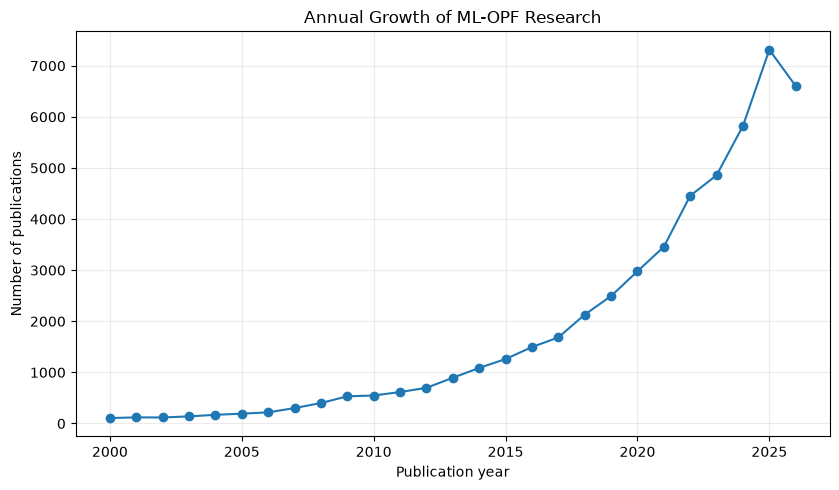

In [11]:
fig, ax = plt.subplots(
    figsize=(8.5, 5.0)
)

ax.plot(
    publication_by_year["Year"],
    publication_by_year["Documents"],
    marker="o",
    linewidth=1.5,
)

ax.set_xlabel(
    "Publication year"
)

ax.set_ylabel(
    "Number of publications"
)

ax.set_title(
    "Annual Growth of ML-OPF Research"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


publication_growth_figure = (
    FIGURE_DIR
    / "scopus_publication_growth.pdf"
)

fig.savefig(
    publication_growth_figure,
    format="pdf",
    bbox_inches="tight",
)

print(
    "Saved:",
    publication_growth_figure
)

plt.show()

In [12]:
# ---------------------------------------------------------
# Construct annual Scopus / patent / policy comparison
# ---------------------------------------------------------

PLOT_START_YEAR = 2015
PLOT_END_YEAR = 2026


# ---------------------------------------------------------
# Helper: clean publication year
# ---------------------------------------------------------

def clean_year(series):

    return pd.to_numeric(
        series,
        errors="coerce",
    )


# ---------------------------------------------------------
# Ensure clean year columns exist
# ---------------------------------------------------------

scopus["Year_clean"] = clean_year(
    scopus["Year"]
)

patent_cited["Year_clean"] = clean_year(
    patent_cited["Year"]
)

policy_cited["Year_clean"] = clean_year(
    policy_cited["Year"]
)


# ---------------------------------------------------------
# Scopus annual publication counts
# ---------------------------------------------------------

scopus_yearly = (
    scopus
    .dropna(
        subset=["Year_clean"]
    )
    .loc[
        lambda df:
            df["Year_clean"].between(
                PLOT_START_YEAR,
                PLOT_END_YEAR,
            )
    ]
    .assign(
        Year=lambda df:
            df["Year_clean"].astype(int)
    )
    .groupby(
        "Year"
    )
    .size()
    .reset_index(
        name="Documents"
    )
)


# ---------------------------------------------------------
# Patent-cited scholarly publications by year
# ---------------------------------------------------------

patent_yearly = (
    patent_cited
    .dropna(
        subset=["Year_clean"]
    )
    .loc[
        lambda df:
            df["Year_clean"].between(
                PLOT_START_YEAR,
                PLOT_END_YEAR,
            )
    ]
    .assign(
        Year=lambda df:
            df["Year_clean"].astype(int)
    )
    .groupby(
        "Year"
    )
    .size()
    .reset_index(
        name="Patent_Cited"
    )
)


# ---------------------------------------------------------
# Policy-cited scholarly publications by year
# ---------------------------------------------------------

policy_yearly = (
    policy_cited
    .dropna(
        subset=["Year_clean"]
    )
    .loc[
        lambda df:
            df["Year_clean"].between(
                PLOT_START_YEAR,
                PLOT_END_YEAR,
            )
    ]
    .assign(
        Year=lambda df:
            df["Year_clean"].astype(int)
    )
    .groupby(
        "Year"
    )
    .size()
    .reset_index(
        name="Policy_Cited"
    )
)


# ---------------------------------------------------------
# Merge all three annual series
# ---------------------------------------------------------

citation_by_year = (
    scopus_yearly
    .merge(
        patent_yearly,
        on="Year",
        how="left",
    )
    .merge(
        policy_yearly,
        on="Year",
        how="left",
    )
    .sort_values(
        "Year"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# Years with no patent/policy-cited publications = 0
# ---------------------------------------------------------

citation_by_year[
    [
        "Patent_Cited",
        "Policy_Cited",
    ]
] = (
    citation_by_year[
        [
            "Patent_Cited",
            "Policy_Cited",
        ]
    ]
    .fillna(0)
    .astype(int)
)


# ---------------------------------------------------------
# Annual citation shares
# ---------------------------------------------------------

citation_by_year[
    "Patent_Rate"
] = (
    100
    * citation_by_year[
        "Patent_Cited"
    ]
    / citation_by_year[
        "Documents"
    ]
)


citation_by_year[
    "Policy_Rate"
] = (
    100
    * citation_by_year[
        "Policy_Cited"
    ]
    / citation_by_year[
        "Documents"
    ]
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

print("ANNUAL EXTERNAL CITATION PATHWAYS")
print("=" * 55)

print(
    "Year range:",
    f"{citation_by_year['Year'].min()}-"
    f"{citation_by_year['Year'].max()}"
)

print(
    "Scopus publications:",
    f"{citation_by_year['Documents'].sum():,}"
)

print(
    "Patent-cited:",
    f"{citation_by_year['Patent_Cited'].sum():,}"
)

print(
    "Policy-cited:",
    f"{citation_by_year['Policy_Cited'].sum():,}"
)

print()

display(
    citation_by_year
)

ANNUAL EXTERNAL CITATION PATHWAYS
Year range: 2015-2026
Scopus publications: 44,550
Patent-cited: 2,477
Policy-cited: 1,706



,Year,Documents,Patent_Cited,Policy_Cited,Patent_Rate,Policy_Rate
0,2015,1261,164,153,13.005551,12.133228
1,2016,1495,163,167,10.903010,11.170569
2,2017,1684,175,191,10.391924,11.342043
3,2018,2129,221,239,10.380460,11.225928
4,2019,2494,282,212,11.307137,8.500401
5,2020,2978,284,192,9.536602,6.447280
6,2021,3457,294,172,8.504484,4.975412
7,2022,4456,277,146,6.216338,3.276481
8,2023,4857,218,119,4.488367,2.450072
9,2024,5823,199,69,3.417482,1.184956


Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/scopus_research_landscape/figures/academic_growth_patent_policy_annotated.pdf


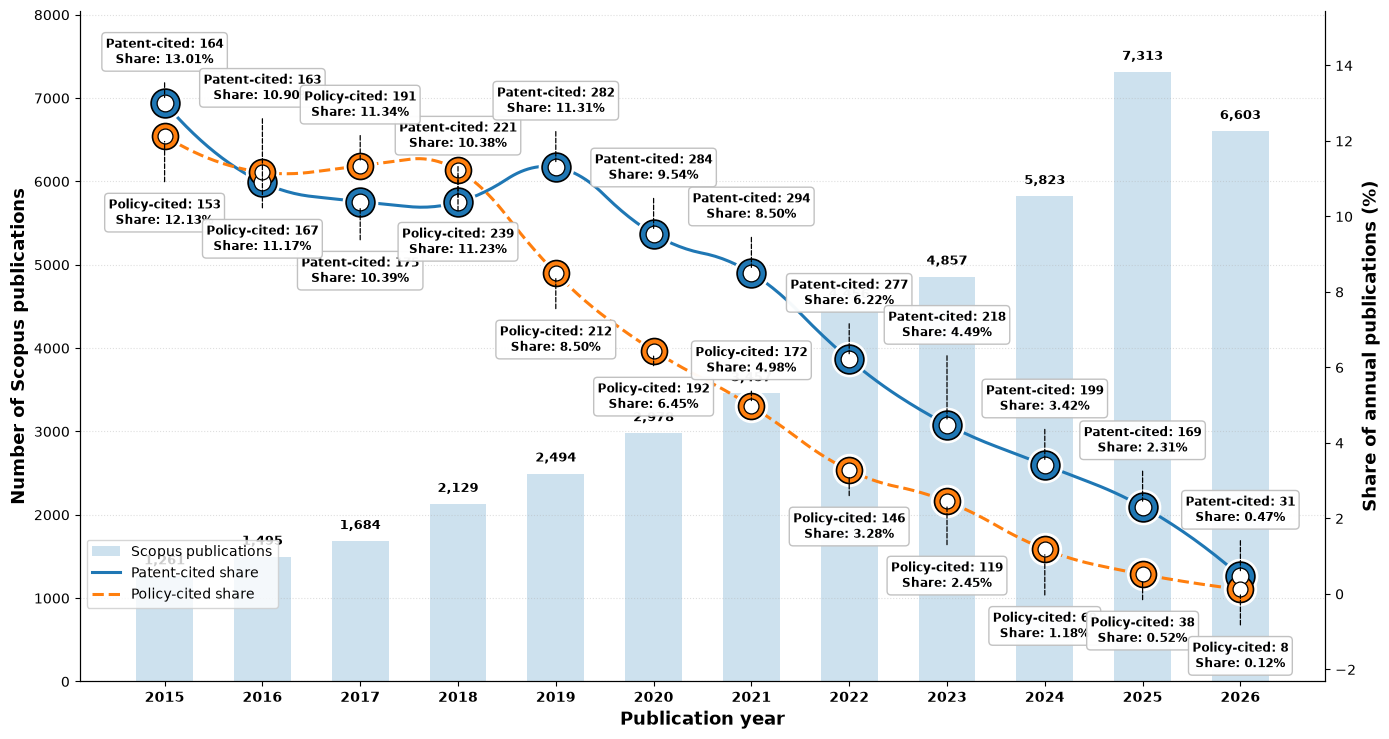

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline


# =====================================================================
# CONFIGURATION
# =====================================================================

PLOT_START_YEAR = 2015
PLOT_END_YEAR = 2026


data = (
    citation_by_year[
        citation_by_year["Year"].between(
            PLOT_START_YEAR,
            PLOT_END_YEAR,
        )
    ]
    .copy()
    .reset_index(drop=True)
)


x = np.arange(len(data))

years = data["Year"].to_numpy()
publications = data["Documents"].to_numpy()

patent_counts = data["Patent_Cited"].to_numpy()
policy_counts = data["Policy_Cited"].to_numpy()

patent_rate = data["Patent_Rate"].to_numpy()
policy_rate = data["Policy_Rate"].to_numpy()


# =====================================================================
# FIGURE
# =====================================================================

fig, ax1 = plt.subplots(
    figsize=(14, 7.5),
    facecolor="white",
)

ax1.set_facecolor("white")


# =====================================================================
# LEFT AXIS — SCOPUS PUBLICATIONS
# =====================================================================

bars = ax1.bar(
    x,
    publications,
    width=0.58,
    alpha=0.22,
    label="Scopus publications",
    zorder=1,
)


# ---------------------------------------------------------
# Publication count on each bar
# ---------------------------------------------------------

bar_offset = (
    publications.max()
    * 0.015
)

for bar, count in zip(
    bars,
    publications,
):

    ax1.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height()
        + bar_offset,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        zorder=3,
    )


# =====================================================================
# RIGHT AXIS — PATENT / POLICY SHARES
# =====================================================================

ax2 = ax1.twinx()


# =====================================================================
# SMOOTH PATENT CURVE
# =====================================================================

x_smooth = np.linspace(
    x.min(),
    x.max(),
    300,
)

patent_spline = make_interp_spline(
    x,
    patent_rate,
    k=2,
)

patent_smooth = patent_spline(
    x_smooth
)

ax2.plot(
    x_smooth,
    patent_smooth,
    linewidth=2.2,
    label="Patent-cited share",
    zorder=3,
)


# =====================================================================
# SMOOTH POLICY CURVE
# =====================================================================

policy_spline = make_interp_spline(
    x,
    policy_rate,
    k=2,
)

policy_smooth = policy_spline(
    x_smooth
)

ax2.plot(
    x_smooth,
    policy_smooth,
    linewidth=2.2,
    linestyle="--",
    label="Policy-cited share",
    zorder=3,
)


# =====================================================================
# DONUT MARKERS
# =====================================================================

for i, xi in enumerate(x):

    # -----------------------------------------------------
    # PATENT — BLUE DONUT
    # -----------------------------------------------------

    yp = patent_rate[i]

    # White halo
    ax2.scatter(
        xi,
        yp,
        s=610,
        facecolor="white",
        zorder=4,
    )

    # Outer blue ring
    ax2.scatter(
        xi,
        yp,
        s=430,
        facecolor="C0",
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )

    # White center
    ax2.scatter(
        xi,
        yp,
        s=145,
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        zorder=6,
    )


    # -----------------------------------------------------
    # POLICY — ORANGE DONUT
    # -----------------------------------------------------

    yq = policy_rate[i]

    # White halo
    ax2.scatter(
        xi,
        yq,
        s=530,
        facecolor="white",
        zorder=4,
    )

    # Outer orange ring
    ax2.scatter(
        xi,
        yq,
        s=350,
        facecolor="C1",
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )

    # White center
    ax2.scatter(
        xi,
        yq,
        s=115,
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        zorder=6,
    )


# =====================================================================
# ANNOTATION SCALE
# =====================================================================

all_rates = np.concatenate(
    [
        patent_rate,
        policy_rate,
    ]
)

rate_range = (
    all_rates.max()
    - all_rates.min()
)

if rate_range <= 0:
    rate_range = 1.0


# Fixed vertical logic:
#
# Patent annotation -> always ABOVE blue circle
# Policy annotation -> always BELOW orange circle
# =====================================================================

patent_offset = (
    rate_range * 0.105
)

policy_offset = (
    rate_range * 0.105
)


# =====================================================================
# PATENT ANNOTATIONS — WITH YEAR-SPECIFIC CUSTOM OFFSETS
# =====================================================================

# Multiplier controls the vertical position relative to the blue circle.
#
#  1.0 = default distance above
# >1.0 = farther above
#  0.0 = approximately at the circle
# <0.0 = move annotation below the circle

patent_offset_multiplier = {
    2015: 0.70,
    2016: 1.55,
    2017: -1.05,
    2018: 1.00,
    2019: 1.00,
    2020: 1.00,
    2021: 1.00,
    2022: 1.00,
    2023: 1.65,
    2024: 1.00,
    2025: 1.00,
    2026: 1.00,
}


for i, xi in enumerate(x):

    year = int(
        data.loc[
            i,
            "Year"
        ]
    )

    # -----------------------------------------------------
    # Year-specific vertical offset
    # -----------------------------------------------------

    multiplier = (
        patent_offset_multiplier.get(
            year,
            1.0,
        )
    )

    current_offset = (
        patent_offset
        * multiplier
    )


    # -----------------------------------------------------
    # Vertical alignment
    #
    # Positive multiplier -> annotation above circle
    # Negative multiplier -> annotation below circle
    # -----------------------------------------------------

    if multiplier >= 0:
        vertical_alignment = "bottom"
    else:
        vertical_alignment = "top"


    # -----------------------------------------------------
    # Annotation
    # -----------------------------------------------------

    ax2.annotate(
        (
            f"Patent-cited: {patent_counts[i]:,}\n"
            f"Share: {patent_rate[i]:.2f}%"
        ),

        xy=(
            xi,
            patent_rate[i],
        ),

        xytext=(
            xi,
            patent_rate[i]
            + current_offset,
        ),

        ha="center",
        va=vertical_alignment,

        fontsize=8.8,
        fontweight="bold",

        bbox=dict(
            boxstyle="round,pad=0.32",
            facecolor="white",
            edgecolor="0.75",
            alpha=0.96,
        ),

        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.9,
            linestyle="--",
            shrinkA=8,
            shrinkB=4,
        ),

        zorder=7,
    )

# =====================================================================
# POLICY ANNOTATIONS — ALWAYS BELOW, WITH CUSTOM OFFSETS
# =====================================================================

# Multiplier controls the vertical distance below the orange circle.
#
# 1.0 = default distance
# >1.0 = move label farther downward
# <1.0 = move label closer to the circle
#
# Add/change years here as needed.

policy_offset_multiplier = {
    2015: 1.20,
    2016: 1.00,
    2017: -1.5,
    2018: 1.10,
    2019: 1.00,
    2020: 0.60,
    2021: -1.20,
    2022: 0.80,
    2023: 1.15,
    2024: 1.20,
    2025: 0.80,
    2026: 1.00,
}


for i, xi in enumerate(x):

    year = int(
        data.loc[
            i,
            "Year"
        ]
    )

    # -----------------------------------------------------
    # Year-specific vertical distance
    # -----------------------------------------------------

    current_offset = (
        policy_offset
        * policy_offset_multiplier.get(
            year,
            1.0,
        )
    )


    # -----------------------------------------------------
    # Annotation
    # -----------------------------------------------------

    ax2.annotate(
        (
            f"Policy-cited: {policy_counts[i]:,}\n"
            f"Share: {policy_rate[i]:.2f}%"
        ),

        # Orange circle
        xy=(
            xi,
            policy_rate[i],
        ),

        # Label always below circle
        xytext=(
            xi,
            policy_rate[i]
            - current_offset,
        ),

        ha="center",
        va="top",

        fontsize=8.8,
        fontweight="bold",

        bbox=dict(
            boxstyle="round,pad=0.32",
            facecolor="white",
            edgecolor="0.75",
            alpha=0.96,
        ),

        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.9,
            linestyle="--",
            shrinkA=8,
            shrinkB=4,
        ),

        zorder=7,
    )


# =====================================================================
# LEFT AXIS FORMATTING
# =====================================================================

ax1.set_xlabel(
    "Publication year",
    fontsize=13,
    fontweight="bold",
)

ax1.set_ylabel(
    "Number of Scopus publications",
    fontsize=13,
    fontweight="bold",
)

ax1.set_xticks(x)

ax1.set_xticklabels(
    years,
    fontsize=10,
    fontweight="bold",
)


# Give publication labels room above bars
ax1.set_ylim(
    0,
    publications.max() * 1.10,
)


# =====================================================================
# RIGHT AXIS FORMATTING
# =====================================================================

ax2.set_ylabel(
    "Share of annual publications (%)",
    fontsize=13,
    fontweight="bold",
)


# Extra room above/below for annotations
ax2.set_ylim(
    min(
        -rate_range * 0.18,
        policy_rate.min()
        - policy_offset * 1.6,
    ),
    patent_rate.max()
    + patent_offset * 1.8,
)


# =====================================================================
# GRID / SPINES
# =====================================================================

ax1.grid(
    axis="y",
    linestyle=":",
    alpha=0.40,
    zorder=0,
)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)


# =====================================================================
# LEGEND
# =====================================================================

handles1, labels1 = (
    ax1.get_legend_handles_labels()
)

handles2, labels2 = (
    ax2.get_legend_handles_labels()
)

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="lower left",
    bbox_to_anchor=(0.00, 0.1),
    frameon=True,
    fontsize=10,
)


# =====================================================================
# TITLE
# =====================================================================

# fig.suptitle(
#     "Academic Growth and External Citation Pathways in ML-OPF Research",
#     x=0.125,
#     y=0.98,
#     ha="left",
#     fontsize=15,
#     fontweight="bold",
# )


fig.tight_layout()


# =====================================================================
# SAVE PDF
# =====================================================================

output_file = (
    FIGURE_DIR
    / "academic_growth_patent_policy_annotated.pdf"
)

fig.savefig(
    output_file,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

print(
    "Saved:",
    output_file
)

plt.show()

## 3. Academic Research Themes

This section identifies the principal thematic structure of the broader
ML-OPF academic literature represented by the full Scopus corpus.

Unlike the subsequent patent- and policy-citation analyses, topic modeling
at this stage is performed on the underlying academic corpus before
external-citation filtering. The resulting topics therefore provide a
baseline representation of the research themes present in the academic
ML-OPF literature.

### 3.1 Prepare the Academic Text Corpus

The academic topic-modeling corpus is constructed from the title and
abstract of each publication in the full Scopus dataset. Combining these
fields provides both the concise topical information contained in titles
and the richer textual content available in abstracts.

Records are retained independently of DOI availability because DOI is
required for linking publications to external databases but is not required
for identifying the thematic structure of the academic literature.

The resulting text corpus is checked for missing and empty documents before
text preprocessing.

In [14]:
# ---------------------------------------------------------
# Prepare full Scopus academic text corpus
# ---------------------------------------------------------

academic_corpus = scopus.copy()


# ---------------------------------------------------------
# Clean title and abstract fields
# ---------------------------------------------------------

academic_corpus["Title_text"] = (
    academic_corpus["Title_clean"]
    .fillna("")
    .astype(str)
    .str.strip()
)

academic_corpus["Abstract_text"] = (
    academic_corpus["Abstract_clean"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# ---------------------------------------------------------
# Combine title + abstract
# ---------------------------------------------------------

academic_corpus["Text"] = (
    academic_corpus["Title_text"]
    + ". "
    + academic_corpus["Abstract_text"]
).str.strip()


# ---------------------------------------------------------
# Remove documents with no usable text
# ---------------------------------------------------------

empty_text_mask = (
    academic_corpus["Text"]
    .str.replace(
        ".",
        "",
        regex=False,
    )
    .str.strip()
    .eq("")
)

n_empty = int(
    empty_text_mask.sum()
)

academic_corpus = (
    academic_corpus[
        ~empty_text_mask
    ]
    .copy()
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Assign stable document ID
# ---------------------------------------------------------

academic_corpus[
    "Document_ID"
] = np.arange(
    1,
    len(academic_corpus) + 1,
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

print("ACADEMIC TOPIC-MODELING CORPUS")
print("=" * 45)

print(
    "Original documents     :",
    f"{len(scopus):,}"
)

print(
    "Documents retained     :",
    f"{len(academic_corpus):,}"
)

print(
    "Empty documents removed:",
    f"{n_empty:,}"
)

print(
    "Non-missing titles     :",
    f"{academic_corpus['Title_text'].ne('').sum():,}"
)

print(
    "Non-missing abstracts  :",
    f"{academic_corpus['Abstract_text'].ne('').sum():,}"
)

print(
    "Documents with DOI     :",
    f"{academic_corpus['DOI_clean'].notna().sum():,}"
)

print(
    "Documents without DOI  :",
    f"{academic_corpus['DOI_clean'].isna().sum():,}"
)


print()
print("Year range")

valid_years = (
    academic_corpus[
        "Year_clean"
    ]
    .dropna()
)

print(
    "Earliest year          :",
    int(valid_years.min())
)

print(
    "Latest year            :",
    int(valid_years.max())
)

ACADEMIC TOPIC-MODELING CORPUS
Original documents     : 50,761
Documents retained     : 50,761
Empty documents removed: 0
Non-missing titles     : 50,761
Non-missing abstracts  : 50,761
Documents with DOI     : 50,761
Documents without DOI  : 0

Year range
Earliest year          : 2000
Latest year            : 2027


In [15]:
ACADEMIC_LDA_DIR = (
    LANDSCAPE_DIR
    / "lda"
)

ACADEMIC_LDA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


academic_corpus_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_corpus.csv"
)


academic_corpus[
    [
        "Document_ID",
        "Title",
        "Year",
        "DOI",
        "Abstract",
        "Text",
    ]
].to_csv(
    academic_corpus_file,
    index=False,
    encoding="utf-8",
)


print(
    "Saved:",
    academic_corpus_file
)

Saved: /nfs/mfirdausi/project/review_paper_fahruddin/output/scopus_research_landscape/lda/scopus_academic_corpus.csv


### 3.2 Text Preprocessing

The academic corpus is preprocessed using the same text-normalization
procedure applied to the citation-selected corpora to maintain methodological
consistency across subsequent comparisons.

Preprocessing includes lowercasing, removal of punctuation and numbers,
English stopword removal, removal of search-query terms, whitespace
normalization, and stemming. Search-query terms are excluded because their
high frequency is partly induced by the literature-retrieval strategy and
therefore provides limited information for distinguishing latent topics.

The preprocessing procedure is implemented in R using the `tm` and
`SnowballC` packages.

In [1]:
# ---------------------------------------------------------
# Text-preprocessing configuration: current Scopus query
# ---------------------------------------------------------

QUERY_STOPWORDS = [
    # Energy block: 3 energy terms × 4 activity terms
    "energy", "power", "electricity",
    "generation", "demand", "load", "consumption",

    # Common forms captured by forecast*
    "forecast", "forecasts", "forecasted", "forecasting",

    # Common forms captured by predict*
    "predict", "predicts", "predicted", "predicting",
    "prediction", "predictions", "predictive",
]

MIN_TERM_LENGTH = 3

print("Query-specific stopwords")
print("=" * 40)
for word in QUERY_STOPWORDS:
    print(" -", word)

print("\nMinimum term length:", MIN_TERM_LENGTH)

Query-specific stopwords
 - energy
 - power
 - electricity
 - generation
 - demand
 - load
 - consumption
 - forecast
 - forecasts
 - forecasted
 - forecasting
 - predict
 - predicts
 - predicted
 - predicting
 - prediction
 - predictions
 - predictive

Minimum term length: 3


# Change `RSCRIPT = Path(`

In [3]:
from pathlib import Path
import subprocess


RSCRIPT = Path(
    r"/nfs/mfirdausi/miniconda3/envs/pytorch/bin/Rscript"
)

if not RSCRIPT.exists():
    raise FileNotFoundError(
        f"Rscript not found: {RSCRIPT}"
    )


r_package_check = subprocess.run(
    [
        str(RSCRIPT),
        "-e",
        (
            'pkgs <- c("tm", "SnowballC", "slam", "topicmodels"); '
            'ok <- sapply(pkgs, requireNamespace, quietly=TRUE); '
            'cat(paste(pkgs, ok, sep="="), sep="\\n")'
        ),
    ],
    capture_output=True,
    text=True,
    check=True,
)


print("Rscript:")
print(RSCRIPT)

print()
print("Required R packages:")
print(
    r_package_check.stdout
)

Rscript:
/nfs/mfirdausi/miniconda3/envs/pytorch/bin/Rscript

Required R packages:
tm=TRUE
SnowballC=TRUE
slam=TRUE
topicmodels=TRUE



In [4]:
# ---------------------------------------------------------
# R preprocessing directory
# ---------------------------------------------------------

R_PREPROCESS_DIR = (
    ACADEMIC_LDA_DIR
    / "r_preprocessing"
)

R_PREPROCESS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "R preprocessing directory:",
    R_PREPROCESS_DIR
)

NameError: name 'ACADEMIC_LDA_DIR' is not defined

In [ ]:
R_PREPROCESS_SCRIPT = (
    R_PREPROCESS_DIR
    / "preprocess_scopus_academic.R"
)


query_stopwords_r = ", ".join(
    [
        f'"{word}"'
        for word in QUERY_STOPWORDS
    ]
)


r_preprocess_code = f'''
args <- commandArgs(
    trailingOnly = TRUE
)

input_file  <- args[1]
output_file <- args[2]

suppressPackageStartupMessages({{
    library(tm)
    library(SnowballC)
}})

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

query_stopwords <- c(
    {query_stopwords_r}
)

# ------------------------------------------------------------
# Load corpus
# ------------------------------------------------------------

data <- read.csv(
    input_file,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    fileEncoding = "UTF-8"
)

if (!"Text" %in% names(data)) {{
    stop(
        "Input file does not contain a Text column."
    )
}}

text <- data$Text

text[is.na(text)] <- ""

# ------------------------------------------------------------
# Construct corpus
# ------------------------------------------------------------

corpus <- VCorpus(
    VectorSource(
        text
    )
)

# ------------------------------------------------------------
# Text preprocessing
# ------------------------------------------------------------

corpus <- tm_map(
    corpus,
    content_transformer(
        tolower
    )
)

corpus <- tm_map(
    corpus,
    removeNumbers
)

corpus <- tm_map(
    corpus,
    removePunctuation
)

corpus <- tm_map(
    corpus,
    removeWords,
    stopwords("english")
)

corpus <- tm_map(
    corpus,
    removeWords,
    query_stopwords
)

corpus <- tm_map(
    corpus,
    stemDocument,
    language = "english"
)

corpus <- tm_map(
    corpus,
    stripWhitespace
)

# ------------------------------------------------------------
# Extract processed text
# ------------------------------------------------------------

processed_text <- sapply(
    corpus,
    content
)

processed_text <- trimws(
    processed_text
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

output <- data.frame(
    Document_ID = data$Document_ID,
    processed_text = processed_text,
    stringsAsFactors = FALSE
)

write.csv(
    output,
    output_file,
    row.names = FALSE,
    fileEncoding = "UTF-8"
)

cat(
    "Documents processed:",
    nrow(output),
    "\\n"
)

cat(
    "Empty documents:",
    sum(
        nchar(
            output$processed_text
        ) == 0
    ),
    "\\n"
)
'''


R_PREPROCESS_SCRIPT.write_text(
    r_preprocess_code,
    encoding="utf-8",
)


print(
    "Created:",
    R_PREPROCESS_SCRIPT
)

In [16]:
processed_file = (
    R_PREPROCESS_DIR
    / "scopus_academic_processed.csv"
)


preprocess_run = subprocess.run(
    [
        str(RSCRIPT),
        str(R_PREPROCESS_SCRIPT),
        str(academic_corpus_file),
        str(processed_file),
    ],
    capture_output=True,
    text=True,
    check=False,
)


print(
    "Return code:",
    preprocess_run.returncode
)


if preprocess_run.stdout.strip():

    print()
    print("R output:")
    print(
        preprocess_run.stdout
    )


if preprocess_run.stderr.strip():

    print()
    print("R messages:")
    print(
        preprocess_run.stderr
    )


if preprocess_run.returncode != 0:

    raise RuntimeError(
        "Scopus academic preprocessing failed."
    )


print()
print(
    "Saved:",
    processed_file
)

Return code: 0

R output:
Documents processed: 16409 
Empty documents: 0 


R messages:
Warning messages:
1: package 'tm' was built under R version 4.5.3 
2: package 'NLP' was built under R version 4.5.3 


Saved: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\r_preprocessing\scopus_academic_processed.csv


### 3.3 Document-Term Matrix Construction

A document-term matrix (DTM) is constructed from the preprocessed Scopus
corpus, with rows representing scholarly publications and columns
representing stemmed terms. Matrix entries record the frequency with which
each term occurs in each document.

At this stage, only the minimum term-length criterion is applied. The raw
DTM is first examined to characterize corpus size, vocabulary size, token
frequency, and the most frequent terms. Document-frequency filtering is
evaluated separately in the following subsection before the final
topic-modeling vocabulary is defined.

In [17]:
# ---------------------------------------------------------
# R script for raw DTM diagnostics
# ---------------------------------------------------------

R_DTM_DIAGNOSTIC_SCRIPT = (
    ACADEMIC_LDA_DIR
    / "dtm_diagnostic_scopus_academic.R"
)


r_dtm_diagnostic_code = r'''
args <- commandArgs(
    trailingOnly = TRUE
)

processed_file <- args[1]
summary_file   <- args[2]
terms_file     <- args[3]

suppressPackageStartupMessages({
    library(tm)
    library(slam)
})

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MIN_TERM_LENGTH <- 3

# ------------------------------------------------------------
# Load processed corpus
# ------------------------------------------------------------

data <- read.csv(
    processed_file,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    fileEncoding = "UTF-8"
)

if (!"processed_text" %in% names(data)) {
    stop(
        "processed_text column not found."
    )
}

processed <- data$processed_text

processed[is.na(processed)] <- ""

# ------------------------------------------------------------
# Construct corpus
# ------------------------------------------------------------

corpus <- VCorpus(
    VectorSource(
        processed
    )
)

# ------------------------------------------------------------
# Construct raw DTM
# ------------------------------------------------------------

dtm <- DocumentTermMatrix(
    corpus,
    control = list(
        wordLengths = c(
            MIN_TERM_LENGTH,
            Inf
        )
    )
)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

document_totals <- slam::row_sums(
    dtm
)

term_totals <- slam::col_sums(
    dtm
)

document_frequency <- slam::col_sums(
    dtm > 0
)

summary_output <- data.frame(
    Documents = nrow(dtm),
    Vocabulary = ncol(dtm),
    Tokens = sum(dtm),
    Min_Term_Length = MIN_TERM_LENGTH,
    Empty_Documents = sum(
        document_totals == 0
    )
)

term_output <- data.frame(
    Term = names(term_totals),
    Frequency = as.numeric(
        term_totals
    ),
    Document_Frequency = as.numeric(
        document_frequency
    ),
    stringsAsFactors = FALSE
)

term_output <- term_output[
    order(
        -term_output$Frequency,
        term_output$Term
    ),
]

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

write.csv(
    summary_output,
    summary_file,
    row.names = FALSE
)

write.csv(
    term_output,
    terms_file,
    row.names = FALSE
)

cat(
    "Documents:",
    nrow(dtm),
    "\n"
)

cat(
    "Vocabulary:",
    ncol(dtm),
    "\n"
)

cat(
    "Tokens:",
    sum(dtm),
    "\n"
)

cat(
    "Empty documents:",
    sum(document_totals == 0),
    "\n"
)
'''


R_DTM_DIAGNOSTIC_SCRIPT.write_text(
    r_dtm_diagnostic_code,
    encoding="utf-8",
)


print(
    "Created:",
    R_DTM_DIAGNOSTIC_SCRIPT
)

Created: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\dtm_diagnostic_scopus_academic.R


In [18]:
# ---------------------------------------------------------
# Output files
# ---------------------------------------------------------

raw_dtm_summary_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_raw_dtm_summary.csv"
)

raw_term_frequency_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_raw_term_frequency.csv"
)


# ---------------------------------------------------------
# Run R
# ---------------------------------------------------------

dtm_run = subprocess.run(
    [
        str(RSCRIPT),
        str(R_DTM_DIAGNOSTIC_SCRIPT),
        str(processed_file),
        str(raw_dtm_summary_file),
        str(raw_term_frequency_file),
    ],
    capture_output=True,
    text=True,
    check=False,
)


print(
    "Return code:",
    dtm_run.returncode
)


if dtm_run.stdout.strip():

    print()
    print("R output:")
    print(
        dtm_run.stdout
    )


if dtm_run.stderr.strip():

    print()
    print("R messages:")
    print(
        dtm_run.stderr
    )


if dtm_run.returncode != 0:

    raise RuntimeError(
        "Raw DTM construction failed."
    )

Return code: 0

R output:
Documents: 16409 
Vocabulary: 46496 
Tokens: 2172293 
Empty documents: 0 


R messages:
Warning messages:
1: package 'tm' was built under R version 4.5.3 
2: package 'NLP' was built under R version 4.5.3 
3: package 'slam' was built under R version 4.5.3 



In [19]:
# ---------------------------------------------------------
# Load DTM diagnostics
# ---------------------------------------------------------

raw_dtm_summary = pd.read_csv(
    raw_dtm_summary_file
)

raw_term_frequency = pd.read_csv(
    raw_term_frequency_file
)


print("RAW SCOPUS DTM")
print("=" * 45)

display(
    raw_dtm_summary
)


print()
print("MOST FREQUENT TERMS")
print("=" * 45)

display(
    raw_term_frequency.head(30)
)

RAW SCOPUS DTM


,Documents,Vocabulary,Tokens,Min_Term_Length,Empty_Documents
0,16409,46496,2172293,3,0



MOST FREQUENT TERMS


,Term,Frequency,Document_Frequency
0,system,37267,11475
1,energi,25216,7303
2,algorithm,23886,8241
3,model,22888,8422
4,propos,22002,10423
5,method,20147,8993
6,use,19967,10225
7,network,17105,6818
8,distribut,16996,5862
9,optim,15922,7854


### 3.4 Document-Frequency Diagnostics and Vocabulary Selection

The raw academic DTM contains a large number of low-frequency terms that may
contribute little to the identification of stable latent topics. A
document-frequency (DF) threshold is therefore applied to remove terms that
occur in only a small proportion of the corpus.

Because the academic Scopus corpus is substantially larger than the
patent-cited and policy-cited corpora, the final threshold is not transferred
directly from those analyses. Instead, several proportional DF thresholds are
evaluated to determine their effects on vocabulary retention.

For a corpus containing \(N\) documents and a proportional threshold \(p\),
the corresponding minimum document frequency is


$DF_{\min} = \left\lceil pN \right\rceil .$


The final threshold is selected after considering vocabulary retention and
the amount of lexical information available for subsequent topic modeling.

In [20]:
# ---------------------------------------------------------
# Document-frequency threshold diagnostics
# ---------------------------------------------------------

DF_PERCENTAGES = [
    0.1,
    0.2,
    0.5,
    1.0,
    1.5,
    2.0,
    2.5,
    3.0,
]


n_documents = int(
    raw_dtm_summary.loc[
        0,
        "Documents"
    ]
)

raw_vocabulary = int(
    raw_dtm_summary.loc[
        0,
        "Vocabulary"
    ]
)


df_diagnostics = []


for df_percent in DF_PERCENTAGES:

    min_df = int(
        np.ceil(
            (df_percent / 100)
            * n_documents
        )
    )

    retained_terms = int(
        (
            raw_term_frequency[
                "Document_Frequency"
            ]
            >= min_df
        )
        .sum()
    )

    removed_terms = (
        raw_vocabulary
        - retained_terms
    )

    retained_percent = (
        100
        * retained_terms
        / raw_vocabulary
    )

    df_diagnostics.append(
        {
            "DF_Percent":
                df_percent,

            "Minimum_DF":
                min_df,

            "Retained_Terms":
                retained_terms,

            "Removed_Terms":
                removed_terms,

            "Vocabulary_Retained_Percent":
                retained_percent,
        }
    )


df_diagnostics = pd.DataFrame(
    df_diagnostics
)


print("SCOPUS DF DIAGNOSTICS")
print("=" * 45)

display(
    df_diagnostics
)

SCOPUS DF DIAGNOSTICS


,DF_Percent,Minimum_DF,Retained_Terms,Removed_Terms,Vocabulary_Retained_Percent
0,0.1,17,4073,42423,8.759893
1,0.2,33,2917,43579,6.273658
2,0.5,83,1842,44654,3.961631
3,1.0,165,1290,45206,2.774432
4,1.5,247,1021,45475,2.195888
5,2.0,329,838,45658,1.802306
6,2.5,411,723,45773,1.554972
7,3.0,493,644,45852,1.385065


In [21]:
df_diagnostics_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_df_diagnostics.csv"
)


df_diagnostics.to_csv(
    df_diagnostics_file,
    index=False,
)


print(
    "Saved:",
    df_diagnostics_file
)

Saved: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_df_diagnostics.csv


Saved: m:\projects_latex\review_paper_2\output\scopus_research_landscape\figures\scopus_df_vocabulary_retention.pdf


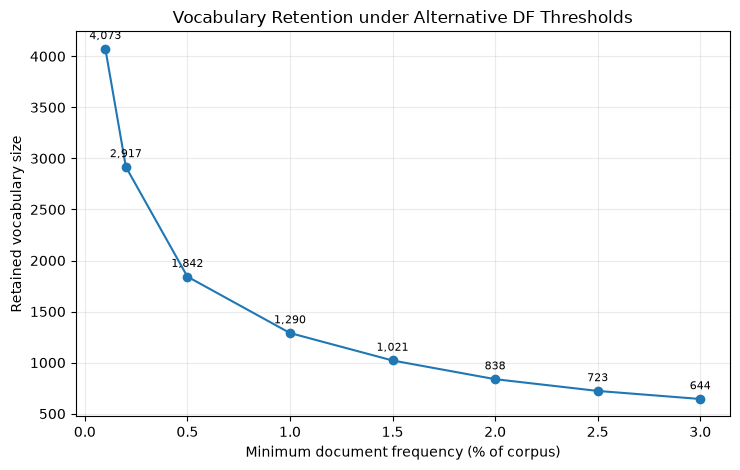

In [22]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)


ax.plot(
    df_diagnostics[
        "DF_Percent"
    ],
    df_diagnostics[
        "Retained_Terms"
    ],
    marker="o",
    linewidth=1.5,
)


for _, row in df_diagnostics.iterrows():

    ax.annotate(
        f"{int(row['Retained_Terms']):,}",
        (
            row["DF_Percent"],
            row["Retained_Terms"],
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )


ax.set_xlabel(
    "Minimum document frequency (% of corpus)"
)

ax.set_ylabel(
    "Retained vocabulary size"
)

ax.set_title(
    "Vocabulary Retention under Alternative DF Thresholds"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


df_figure = (
    FIGURE_DIR
    / "scopus_df_vocabulary_retention.pdf"
)


fig.savefig(
    df_figure,
    format="pdf",
    bbox_inches="tight",
)


print(
    "Saved:",
    df_figure
)

plt.show()

In [23]:
for df_percent in [
    0.1,
    0.2,
    0.5,
    1.0,
]:

    min_df = int(
        np.ceil(
            (df_percent / 100)
            * n_documents
        )
    )

    retained = (
        raw_term_frequency[
            raw_term_frequency[
                "Document_Frequency"
            ]
            >= min_df
        ]
        .copy()
    )

    print()
    print(
        f"DF >= {df_percent}% "
        f"(minimum {min_df:,} documents)"
    )

    print(
        "Retained terms:",
        f"{len(retained):,}"
    )

    print(
        "Lowest-frequency retained examples:"
    )

    display(
        retained[
            [
                "Term",
                "Frequency",
                "Document_Frequency",
            ]
        ]
        .sort_values(
            "Document_Frequency"
        )
        .head(20)
    )


DF >= 0.1% (minimum 17 documents)
Retained terms: 4,073
Lowest-frequency retained examples:


,Term,Frequency,Document_Frequency
4712,fmeasur,18,17
4713,fortifi,18,17
4543,admit,19,17
4599,inerti,19,17
4606,kfold,19,17
4626,night,19,17
4927,tabular,17,17
4720,intelligencedriven,18,17
4722,invalu,18,17
4725,kirchhoff,18,17



DF >= 0.2% (minimum 33 documents)
Retained terms: 2,917
Lowest-frequency retained examples:


,Term,Frequency,Document_Frequency
3487,worth,33,33
3123,ita,41,33
3132,proton,41,33
3184,underestim,40,33
2585,interarea,58,33
3238,half,38,33
3016,healthi,44,33
3262,zhang,38,33
2954,biobject,45,33
2640,gridform,56,33



DF >= 0.5% (minimum 83 documents)
Retained terms: 1,842
Lowest-frequency retained examples:


,Term,Frequency,Document_Frequency
2129,iop,84,83
1988,systemlevel,98,83
2008,capit,95,83
1914,instrument,105,83
1849,workflow,113,83
1803,ppo,118,83
1844,purchas,113,83
1741,pvs,124,83
2024,generaliz,94,83
2083,phenomenon,88,83



DF >= 1.0% (minimum 165 documents)
Retained terms: 1,290
Lowest-frequency retained examples:


,Term,Frequency,Document_Frequency
1472,turn,169,165
1469,serious,170,165
1465,emphasi,170,165
1362,sum,196,165
1094,fair,291,165
1238,entiti,229,166
962,feder,356,166
1365,quantiti,195,166
1455,easi,173,167
1320,deliveri,206,167


#### 3.4.1 Final Document-Frequency Threshold

Based on the document-frequency diagnostics, a minimum document-frequency
threshold of **0.5% of the academic corpus** is adopted for the Scopus topic
model.

For the 16,409-document corpus, this corresponds to

$$
DF_{\min}
=
\left\lceil
0.005 \times 16{,}409
\right\rceil
=
83.
$$

The threshold reduces the raw vocabulary from 46,496 terms to 1,842 terms.
This substantially removes the low-frequency lexical tail while retaining a
sufficiently broad vocabulary for identifying both dominant and more
specialized academic research themes.

This threshold is specific to the academic corpus and is not required to
match the thresholds used for the smaller patent-cited and policy-cited
corpora.

In [24]:
# ---------------------------------------------------------
# Final document-frequency threshold
# ---------------------------------------------------------

FINAL_DF_PERCENT = 0.5

FINAL_MIN_DOC_FREQ = int(
    np.ceil(
        (FINAL_DF_PERCENT / 100)
        * len(academic_corpus)
    )
)


print("FINAL SCOPUS DTM CONFIGURATION")
print("=" * 45)

print(
    "Documents             :",
    f"{len(academic_corpus):,}"
)

print(
    "DF threshold          :",
    f"{FINAL_DF_PERCENT}%"
)

print(
    "Minimum document freq.:",
    f"{FINAL_MIN_DOC_FREQ:,}"
)

FINAL SCOPUS DTM CONFIGURATION
Documents             : 16,409
DF threshold          : 0.5%
Minimum document freq.: 83


In [25]:
R_FINAL_DTM_SCRIPT = (
    ACADEMIC_LDA_DIR
    / "final_dtm_scopus_academic.R"
)


r_final_dtm_code = r'''
args <- commandArgs(
    trailingOnly = TRUE
)

processed_file <- args[1]
summary_file   <- args[2]
terms_file     <- args[3]
min_doc_freq   <- as.integer(args[4])

suppressPackageStartupMessages({
    library(tm)
    library(slam)
})

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MIN_TERM_LENGTH <- 3

# ------------------------------------------------------------
# Load processed corpus
# ------------------------------------------------------------

data <- read.csv(
    processed_file,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    fileEncoding = "UTF-8"
)

processed <- data$processed_text

processed[is.na(processed)] <- ""

# ------------------------------------------------------------
# Construct DTM
# ------------------------------------------------------------

corpus <- VCorpus(
    VectorSource(
        processed
    )
)

dtm <- DocumentTermMatrix(
    corpus,
    control = list(
        wordLengths = c(
            MIN_TERM_LENGTH,
            Inf
        )
    )
)

# ------------------------------------------------------------
# Document-frequency filtering
# ------------------------------------------------------------

document_frequency <- slam::col_sums(
    dtm > 0
)

dtm <- dtm[
    ,
    document_frequency >= min_doc_freq
]

# ------------------------------------------------------------
# Final diagnostics
# ------------------------------------------------------------

document_totals <- slam::row_sums(
    dtm
)

term_totals <- slam::col_sums(
    dtm
)

final_document_frequency <- slam::col_sums(
    dtm > 0
)

summary_output <- data.frame(
    Documents = nrow(dtm),
    Vocabulary = ncol(dtm),
    Tokens = sum(dtm),
    Minimum_DF = min_doc_freq,
    Min_Term_Length = MIN_TERM_LENGTH,
    Empty_Documents = sum(
        document_totals == 0
    )
)

term_output <- data.frame(
    Term = names(term_totals),
    Frequency = as.numeric(
        term_totals
    ),
    Document_Frequency = as.numeric(
        final_document_frequency
    ),
    stringsAsFactors = FALSE
)

term_output <- term_output[
    order(
        -term_output$Frequency,
        term_output$Term
    ),
]

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

write.csv(
    summary_output,
    summary_file,
    row.names = FALSE
)

write.csv(
    term_output,
    terms_file,
    row.names = FALSE
)

cat(
    "Documents:",
    nrow(dtm),
    "\n"
)

cat(
    "Vocabulary:",
    ncol(dtm),
    "\n"
)

cat(
    "Tokens:",
    sum(dtm),
    "\n"
)

cat(
    "Minimum DF:",
    min_doc_freq,
    "\n"
)

cat(
    "Empty documents:",
    sum(document_totals == 0),
    "\n"
)
'''


R_FINAL_DTM_SCRIPT.write_text(
    r_final_dtm_code,
    encoding="utf-8",
)

print(
    "Created:",
    R_FINAL_DTM_SCRIPT
)

Created: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\final_dtm_scopus_academic.R


In [26]:
final_dtm_summary_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_dtm_summary.csv"
)

final_dtm_terms_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_dtm_terms.csv"
)


final_dtm_run = subprocess.run(
    [
        str(RSCRIPT),
        str(R_FINAL_DTM_SCRIPT),
        str(processed_file),
        str(final_dtm_summary_file),
        str(final_dtm_terms_file),
        str(FINAL_MIN_DOC_FREQ),
    ],
    capture_output=True,
    text=True,
    check=False,
)


print(
    "Return code:",
    final_dtm_run.returncode
)

if final_dtm_run.stdout.strip():

    print()
    print("R output:")
    print(
        final_dtm_run.stdout
    )

if final_dtm_run.stderr.strip():

    print()
    print("R messages:")
    print(
        final_dtm_run.stderr
    )

if final_dtm_run.returncode != 0:

    raise RuntimeError(
        "Final Scopus DTM construction failed."
    )

Return code: 0

R output:
Documents: 16409 
Vocabulary: 1842 
Tokens: 1927662 
Minimum DF: 83 
Empty documents: 0 


R messages:
Warning messages:
1: package 'tm' was built under R version 4.5.3 
2: package 'NLP' was built under R version 4.5.3 
3: package 'slam' was built under R version 4.5.3 



In [27]:
final_dtm_summary = pd.read_csv(
    final_dtm_summary_file
)

final_dtm_terms = pd.read_csv(
    final_dtm_terms_file
)


print("FINAL SCOPUS DTM")
print("=" * 45)

display(
    final_dtm_summary
)


print()
print("MOST FREQUENT RETAINED TERMS")
print("=" * 45)

display(
    final_dtm_terms.head(30)
)

FINAL SCOPUS DTM


,Documents,Vocabulary,Tokens,Minimum_DF,Min_Term_Length,Empty_Documents
0,16409,1842,1927662,83,3,0



MOST FREQUENT RETAINED TERMS


,Term,Frequency,Document_Frequency
0,system,37267,11475
1,energi,25216,7303
2,algorithm,23886,8241
3,model,22888,8422
4,propos,22002,10423
5,method,20147,8993
6,use,19967,10225
7,network,17105,6818
8,distribut,16996,5862
9,optim,15922,7854


#### 3.4.2 Save the Final Document-Term Matrix

The finalized document-term matrix is stored in sparse triplet form for
subsequent topic-model estimation. This representation records only nonzero
document--term entries and avoids the storage overhead associated with a
dense matrix.

The corresponding vocabulary and DTM summary are retained separately to
preserve the mapping between term indices and processed terms.

In [28]:
R_SAVE_DTM_SCRIPT = (
    ACADEMIC_LDA_DIR
    / "save_scopus_academic_dtm.R"
)


r_save_dtm_code = r'''
args <- commandArgs(
    trailingOnly = TRUE
)

processed_file <- args[1]
dtm_file       <- args[2]
vocab_file     <- args[3]
min_doc_freq   <- as.integer(args[4])

suppressPackageStartupMessages({
    library(tm)
    library(slam)
})

MIN_TERM_LENGTH <- 3

# ------------------------------------------------------------
# Load processed corpus
# ------------------------------------------------------------

data <- read.csv(
    processed_file,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    fileEncoding = "UTF-8"
)

processed <- data$processed_text
processed[is.na(processed)] <- ""

# ------------------------------------------------------------
# Construct DTM
# ------------------------------------------------------------

corpus <- VCorpus(
    VectorSource(
        processed
    )
)

dtm <- DocumentTermMatrix(
    corpus,
    control = list(
        wordLengths = c(
            MIN_TERM_LENGTH,
            Inf
        )
    )
)

# ------------------------------------------------------------
# Apply final document-frequency filter
# ------------------------------------------------------------

document_frequency <- slam::col_sums(
    dtm > 0
)

dtm <- dtm[
    ,
    document_frequency >= min_doc_freq
]

# ------------------------------------------------------------
# Verify no empty documents
# ------------------------------------------------------------

empty_documents <- (
    slam::row_sums(dtm) == 0
)

if (any(empty_documents)) {

    stop(
        paste(
            "Final DTM contains",
            sum(empty_documents),
            "empty documents."
        )
    )
}

# ------------------------------------------------------------
# Convert to sparse triplet representation
# ------------------------------------------------------------

dtm_triplet <- as.simple_triplet_matrix(
    dtm
)

triplet_output <- data.frame(
    Document_ID = dtm_triplet$i,
    Term_ID = dtm_triplet$j,
    Frequency = dtm_triplet$v
)

# ------------------------------------------------------------
# Vocabulary
# ------------------------------------------------------------

vocabulary_output <- data.frame(
    Term_ID = seq_len(
        ncol(dtm)
    ),
    Term = Terms(dtm),
    stringsAsFactors = FALSE
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

write.csv(
    triplet_output,
    dtm_file,
    row.names = FALSE
)

write.csv(
    vocabulary_output,
    vocab_file,
    row.names = FALSE
)

cat(
    "Documents:",
    nrow(dtm),
    "\n"
)

cat(
    "Vocabulary:",
    ncol(dtm),
    "\n"
)

cat(
    "Tokens:",
    sum(dtm),
    "\n"
)

cat(
    "Nonzero entries:",
    length(dtm_triplet$v),
    "\n"
)

cat(
    "Empty documents:",
    sum(empty_documents),
    "\n"
)
'''


R_SAVE_DTM_SCRIPT.write_text(
    r_save_dtm_code,
    encoding="utf-8",
)

print(
    "Created:",
    R_SAVE_DTM_SCRIPT
)

Created: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\save_scopus_academic_dtm.R


In [29]:
final_dtm_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_dtm.csv"
)

final_vocabulary_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_vocabulary.csv"
)


save_dtm_run = subprocess.run(
    [
        str(RSCRIPT),
        str(R_SAVE_DTM_SCRIPT),
        str(processed_file),
        str(final_dtm_file),
        str(final_vocabulary_file),
        str(FINAL_MIN_DOC_FREQ),
    ],
    capture_output=True,
    text=True,
    check=False,
)


print(
    "Return code:",
    save_dtm_run.returncode
)

if save_dtm_run.stdout.strip():

    print()
    print("R output:")
    print(
        save_dtm_run.stdout
    )

if save_dtm_run.stderr.strip():

    print()
    print("R messages:")
    print(
        save_dtm_run.stderr
    )

if save_dtm_run.returncode != 0:

    raise RuntimeError(
        "Saving final Scopus DTM failed."
    )


print()
print(
    "DTM saved       :",
    final_dtm_file
)

print(
    "Vocabulary saved:",
    final_vocabulary_file
)

Return code: 0

R output:
Documents: 16409 
Vocabulary: 1842 
Tokens: 1927662 
Nonzero entries: 1300540 
Empty documents: 0 


R messages:
Warning messages:
1: package 'tm' was built under R version 4.5.3 
2: package 'NLP' was built under R version 4.5.3 
3: package 'slam' was built under R version 4.5.3 


DTM saved       : m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_final_dtm.csv
Vocabulary saved: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_final_vocabulary.csv


### 3.5 LDA Topic-Number Selection

The number of latent topics is selected empirically rather than fixed in
advance. Candidate LDA models are estimated using a reproducible training
and held-out split of the academic corpus.

An initial coarse search is used to examine held-out perplexity across a
range of topic numbers. Lower perplexity indicates better predictive
performance on unseen documents. Because perplexity alone does not guarantee
substantively coherent or distinct topics, the coarse search is used only
to identify the region in which additional topics provide diminishing
improvements.

Candidate models within the resulting range are subsequently evaluated using
held-out perplexity, semantic coherence, inter-topic similarity, and manual
interpretability.

In [30]:
TRAIN_FRACTION = 0.80
RANDOM_SEED = 123

K_COARSE = [
    5,
    10,
    15,
    20,
    25,
    30,
    40,
    50,
    60,
]


print(
    "Training fraction :",
    TRAIN_FRACTION
)

print(
    "Random seed       :",
    RANDOM_SEED
)

print(
    "Coarse K values   :",
    K_COARSE
)

Training fraction : 0.8
Random seed       : 123
Coarse K values   : [5, 10, 15, 20, 25, 30, 40, 50, 60]


In [31]:
# ---------------------------------------------------------
# Reproducible train / held-out split
# ---------------------------------------------------------

rng = np.random.default_rng(
    RANDOM_SEED
)

n_documents = len(
    academic_corpus
)

all_indices = np.arange(
    1,
    n_documents + 1,
)

shuffled = rng.permutation(
    all_indices
)

n_train = int(
    np.floor(
        TRAIN_FRACTION
        * n_documents
    )
)

train_id = np.sort(
    shuffled[
        :n_train
    ]
)

test_id = np.sort(
    shuffled[
        n_train:
    ]
)


# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

train_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_train_indices.csv"
)

test_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_test_indices.csv"
)


pd.DataFrame({
    "train_id": train_id
}).to_csv(
    train_file,
    index=False,
)


pd.DataFrame({
    "test_id": test_id
}).to_csv(
    test_file,
    index=False,
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

print("SCOPUS ACADEMIC TRAIN / TEST SPLIT")
print("=" * 45)

print(
    "Total documents   :",
    f"{n_documents:,}"
)

print(
    "Training documents:",
    f"{len(train_id):,}"
)

print(
    "Held-out documents:",
    f"{len(test_id):,}"
)

print(
    "Overlap           :",
    len(
        set(train_id)
        & set(test_id)
    )
)

print(
    "Complete coverage :",
    len(
        set(train_id)
        | set(test_id)
    )
    == n_documents
)

SCOPUS ACADEMIC TRAIN / TEST SPLIT
Total documents   : 16,409
Training documents: 13,127
Held-out documents: 3,282
Overlap           : 0
Complete coverage : True


#### 3.5.2 Coarse Topic-Number Search

A coarse search is first performed across a broad range of topic numbers
using the fixed training and held-out document sets.

For each candidate number of topics, an LDA model is estimated on the
training corpus and evaluated using perplexity on the held-out corpus.
Perplexity is defined as

$$
\operatorname{Perplexity}
=
\exp
\left(
-\frac{\log p(\mathbf{W}_{\mathrm{test}})}
{\sum_d N_d}
\right),
$$

where $\mathbf{W}_{\mathrm{test}}$ denotes the held-out documents and
$N_d$ is the number of observed tokens in document $d$.

Lower held-out perplexity indicates better predictive performance. The
coarse search is used to identify the range in which increasing the number
of topics begins to yield diminishing improvements rather than to determine
the final topic number by perplexity alone.

In [32]:
R_COARSE_SEARCH_SCRIPT = (
    ACADEMIC_LDA_DIR
    / "coarse_k_search_scopus_academic.R"
)


k_values_r = ", ".join(
    str(k)
    for k in K_COARSE
)


r_coarse_search_code = f'''
args <- commandArgs(
    trailingOnly = TRUE
)

processed_file <- args[1]
train_file     <- args[2]
test_file      <- args[3]
output_file    <- args[4]
min_doc_freq   <- as.integer(args[5])

suppressPackageStartupMessages({{
    library(tm)
    library(slam)
    library(topicmodels)
}})

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MIN_TERM_LENGTH <- 3

K_VALUES <- c(
    {k_values_r}
)

RANDOM_SEED <- 123

# Lightweight Gibbs configuration for coarse search.
BURN_IN <- 200
ITERATIONS <- 800
THIN <- 20

# ------------------------------------------------------------
# Load processed corpus
# ------------------------------------------------------------

data <- read.csv(
    processed_file,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    fileEncoding = "UTF-8"
)

processed <- data$processed_text
processed[is.na(processed)] <- ""

# ------------------------------------------------------------
# Construct DTM
# ------------------------------------------------------------

corpus <- VCorpus(
    VectorSource(
        processed
    )
)

dtm <- DocumentTermMatrix(
    corpus,
    control = list(
        wordLengths = c(
            MIN_TERM_LENGTH,
            Inf
        )
    )
)

# ------------------------------------------------------------
# Apply final document-frequency threshold
# ------------------------------------------------------------

document_frequency <- slam::col_sums(
    dtm > 0
)

dtm <- dtm[
    ,
    document_frequency >= min_doc_freq
]

# ------------------------------------------------------------
# Load fixed train / held-out split
# ------------------------------------------------------------

train_id <- read.csv(
    train_file
)$train_id

test_id <- read.csv(
    test_file
)$test_id

dtm_train <- dtm[
    train_id,
]

dtm_test <- dtm[
    test_id,
]

# ------------------------------------------------------------
# Restrict vocabulary to terms occurring in training data
# ------------------------------------------------------------

training_term_mask <- (
    slam::col_sums(
        dtm_train
    ) > 0
)

dtm_train <- dtm_train[
    ,
    training_term_mask
]

dtm_test <- dtm_test[
    ,
    training_term_mask
]

# ------------------------------------------------------------
# Remove empty documents, if any
# ------------------------------------------------------------

train_nonempty <- (
    slam::row_sums(
        dtm_train
    ) > 0
)

test_nonempty <- (
    slam::row_sums(
        dtm_test
    ) > 0
)

n_empty_train <- sum(
    !train_nonempty
)

n_empty_test <- sum(
    !test_nonempty
)

dtm_train <- dtm_train[
    train_nonempty,
]

dtm_test <- dtm_test[
    test_nonempty,
]

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

cat(
    "Training documents:",
    nrow(dtm_train),
    "\\n"
)

cat(
    "Held-out documents:",
    nrow(dtm_test),
    "\\n"
)

cat(
    "Vocabulary:",
    ncol(dtm_train),
    "\\n"
)

cat(
    "Minimum DF:",
    min_doc_freq,
    "\\n"
)

cat(
    "Empty training removed:",
    n_empty_train,
    "\\n"
)

cat(
    "Empty held-out removed:",
    n_empty_test,
    "\\n\\n"
)

# ------------------------------------------------------------
# Coarse K search
# ------------------------------------------------------------

results <- data.frame()

for (k in K_VALUES) {{

    cat(
        "Fitting K =",
        k,
        "... "
    )

    flush.console()

    start_time <- Sys.time()

    model <- topicmodels::LDA(
        dtm_train,
        k = k,
        method = "Gibbs",
        control = list(
            seed = RANDOM_SEED,
            burnin = BURN_IN,
            iter = ITERATIONS,
            thin = THIN
        )
    )

    heldout_perplexity <- (
        topicmodels::perplexity(
            model,
            newdata = dtm_test
        )
    )

    elapsed <- as.numeric(
        difftime(
            Sys.time(),
            start_time,
            units = "secs"
        )
    )

    results <- rbind(
        results,
        data.frame(
            K = k,
            Perplexity =
                heldout_perplexity,
            Elapsed_seconds =
                elapsed
        )
    )

    # Save incrementally.
    write.csv(
        results,
        output_file,
        row.names = FALSE
    )

    cat(
        sprintf(
            "perplexity = %.4f | %.2f s\\n",
            heldout_perplexity,
            elapsed
        )
    )

    flush.console()
}}
'''


R_COARSE_SEARCH_SCRIPT.write_text(
    r_coarse_search_code,
    encoding="utf-8",
)


print(
    "Created:",
    R_COARSE_SEARCH_SCRIPT
)

Created: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\coarse_k_search_scopus_academic.R


In [33]:
# ---------------------------------------------------------
# Coarse K-search
#
# Set True only when the coarse search must be recomputed.
# Normally keep False and load the saved result.
# ---------------------------------------------------------

RUN_COARSE_SEARCH = False


coarse_results_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_coarse_k_search.csv"
)


if RUN_COARSE_SEARCH:

    print("Running Scopus academic coarse K search...")
    print("=" * 50)

    print(
        "Documents  :",
        f"{len(academic_corpus):,}"
    )

    print(
        "Minimum DF :",
        FINAL_MIN_DOC_FREQ
    )

    print(
        "K values   :",
        K_COARSE
    )


    coarse_run = subprocess.run(
        [
            str(RSCRIPT),
            str(R_COARSE_SEARCH_SCRIPT),
            str(processed_file),
            str(train_file),
            str(test_file),
            str(coarse_results_file),
            str(FINAL_MIN_DOC_FREQ),
        ],
        capture_output=True,
        text=True,
        check=False,
    )


    print()
    print(
        "Return code:",
        coarse_run.returncode
    )


    if coarse_run.stdout.strip():

        print()
        print("R output:")

        print(
            coarse_run.stdout
        )


    if coarse_run.stderr.strip():

        print()
        print("R messages:")

        print(
            coarse_run.stderr
        )


    if coarse_run.returncode != 0:

        raise RuntimeError(
            "Scopus academic coarse K search failed."
        )


else:

    print(
        "Skipping coarse K search; "
        "loading existing saved results."
    )


# ---------------------------------------------------------
# Load results
# ---------------------------------------------------------

if not coarse_results_file.exists():

    raise FileNotFoundError(
        "Coarse K-search result not found:\n"
        f"{coarse_results_file}\n\n"
        "Either copy the completed ISS result here "
        "or set RUN_COARSE_SEARCH = True."
    )


coarse_results = pd.read_csv(
    coarse_results_file
)


coarse_results = (
    coarse_results
    .sort_values("K")
    .reset_index(drop=True)
)


print()
print("SCOPUS ACADEMIC COARSE K SEARCH")
print("=" * 50)

print(
    "K values:",
    coarse_results[
        "K"
    ].tolist()
)

print()

display(
    coarse_results
)

Skipping coarse K search; loading existing saved results.

SCOPUS ACADEMIC COARSE K SEARCH
K values: [5, 10, 15, 20, 25, 30, 40, 50, 60]



,K,Perplexity,Elapsed_seconds,Training_documents,Heldout_documents,Vocabulary,Empty_training_removed,Empty_heldout_removed
0,5,631.113858,42.805920,13127,3282,1842,0,0
1,10,577.845145,50.525000,13127,3282,1842,0,0
2,15,548.458643,58.352061,13127,3282,1842,0,0
3,20,527.031296,67.123267,13127,3282,1842,0,0
4,25,508.991746,71.440444,13127,3282,1842,0,0
5,30,495.941003,78.838288,13127,3282,1842,0,0
6,40,469.197113,97.712219,13127,3282,1842,0,0
7,50,448.785508,111.129047,13127,3282,1842,0,0
8,60,433.157316,126.543503,13127,3282,1842,0,0


In [34]:
# ---------------------------------------------------------
# Load coarse K-search results computed on ISS
# ---------------------------------------------------------

coarse_results_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_coarse_k_search.csv"
)


if not coarse_results_file.exists():

    raise FileNotFoundError(
        "Coarse K-search result not found:\n"
        f"{coarse_results_file}"
    )


coarse_results = pd.read_csv(
    coarse_results_file
)


coarse_results = (
    coarse_results
    .sort_values("K")
    .reset_index(drop=True)
)


print("SCOPUS ACADEMIC COARSE K SEARCH")
print("=" * 50)

print(
    "Result source : ISS parallel computation"
)

print(
    "K values      :",
    coarse_results["K"].tolist()
)

print()

display(
    coarse_results
)

SCOPUS ACADEMIC COARSE K SEARCH
Result source : ISS parallel computation
K values      : [5, 10, 15, 20, 25, 30, 40, 50, 60]



,K,Perplexity,Elapsed_seconds,Training_documents,Heldout_documents,Vocabulary,Empty_training_removed,Empty_heldout_removed
0,5,631.113858,42.805920,13127,3282,1842,0,0
1,10,577.845145,50.525000,13127,3282,1842,0,0
2,15,548.458643,58.352061,13127,3282,1842,0,0
3,20,527.031296,67.123267,13127,3282,1842,0,0
4,25,508.991746,71.440444,13127,3282,1842,0,0
5,30,495.941003,78.838288,13127,3282,1842,0,0
6,40,469.197113,97.712219,13127,3282,1842,0,0
7,50,448.785508,111.129047,13127,3282,1842,0,0
8,60,433.157316,126.543503,13127,3282,1842,0,0


In [35]:
# ---------------------------------------------------------
# Load extended K-search results computed on ISS
# ---------------------------------------------------------

extended_results_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_extended_k_search.csv"
)


if not extended_results_file.exists():

    raise FileNotFoundError(
        "Extended K-search result not found:\n"
        f"{extended_results_file}"
    )


extended_results = pd.read_csv(
    extended_results_file
)


extended_results = (
    extended_results
    .sort_values("K")
    .reset_index(drop=True)
)


print("SCOPUS ACADEMIC EXTENDED K SEARCH")
print("=" * 50)

print(
    "Result source : ISS parallel computation"
)

print(
    "K values      :",
    extended_results["K"].tolist()
)

print()

display(
    extended_results
)

SCOPUS ACADEMIC EXTENDED K SEARCH
Result source : ISS parallel computation
K values      : [70, 80, 90]



,K,Perplexity,Elapsed_seconds,Training_documents,Heldout_documents,Vocabulary,Empty_training_removed,Empty_heldout_removed
0,70,418.181869,141.292716,13127,3282,1842,0,0
1,80,407.145951,162.925877,13127,3282,1842,0,0
2,90,397.771136,182.042221,13127,3282,1842,0,0


In [36]:
# ---------------------------------------------------------
# Combine coarse and extended K-search results
# ---------------------------------------------------------

k_search_results = (
    pd.concat(
        [
            coarse_results,
            extended_results,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        subset=["K"],
        keep="last",
    )
    .sort_values("K")
    .reset_index(drop=True)
)


print("COMPLETE SCOPUS ACADEMIC K SEARCH")
print("=" * 50)

print(
    "K values:",
    k_search_results["K"].tolist()
)

print()

display(
    k_search_results
)

COMPLETE SCOPUS ACADEMIC K SEARCH
K values: [5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90]



,K,Perplexity,Elapsed_seconds,Training_documents,Heldout_documents,Vocabulary,Empty_training_removed,Empty_heldout_removed
0,5,631.113858,42.805920,13127,3282,1842,0,0
1,10,577.845145,50.525000,13127,3282,1842,0,0
2,15,548.458643,58.352061,13127,3282,1842,0,0
3,20,527.031296,67.123267,13127,3282,1842,0,0
4,25,508.991746,71.440444,13127,3282,1842,0,0
5,30,495.941003,78.838288,13127,3282,1842,0,0
6,40,469.197113,97.712219,13127,3282,1842,0,0
7,50,448.785508,111.129047,13127,3282,1842,0,0
8,60,433.157316,126.543503,13127,3282,1842,0,0
9,70,418.181869,141.292716,13127,3282,1842,0,0


In [37]:
# ---------------------------------------------------------
# Perplexity improvement diagnostics
# ---------------------------------------------------------

k_diagnostics = (
    k_search_results[
        [
            "K",
            "Perplexity",
        ]
    ]
    .copy()
)


# Increase in K from previous candidate
k_diagnostics[
    "Delta_K"
] = (
    k_diagnostics["K"]
    .diff()
)


# Absolute reduction in perplexity
k_diagnostics[
    "Perplexity_Reduction"
] = (
    -k_diagnostics[
        "Perplexity"
    ]
    .diff()
)


# Reduction normalized by number of added topics
k_diagnostics[
    "Reduction_Per_Added_Topic"
] = (
    k_diagnostics[
        "Perplexity_Reduction"
    ]
    /
    k_diagnostics[
        "Delta_K"
    ]
)


# Percentage reduction relative to previous perplexity
k_diagnostics[
    "Relative_Reduction_Percent"
] = (
    100
    * k_diagnostics[
        "Perplexity_Reduction"
    ]
    /
    k_diagnostics[
        "Perplexity"
    ]
    .shift(1)
)


print("PERPLEXITY DIMINISHING-RETURN DIAGNOSTICS")
print("=" * 60)

display(
    k_diagnostics
)

PERPLEXITY DIMINISHING-RETURN DIAGNOSTICS


,K,Perplexity,Delta_K,Perplexity_Reduction,Reduction_Per_Added_Topic,Relative_Reduction_Percent
0,5,631.113858,NaN,NaN,NaN,NaN
1,10,577.845145,5.0,53.268713,10.653743,8.440428
2,15,548.458643,5.0,29.386502,5.877300,5.085532
3,20,527.031296,5.0,21.427347,4.285469,3.906830
4,25,508.991746,5.0,18.039550,3.607910,3.422861
5,30,495.941003,5.0,13.050743,2.610149,2.564038
6,40,469.197113,10.0,26.743890,2.674389,5.392555
7,50,448.785508,10.0,20.411605,2.041160,4.350326
8,60,433.157316,10.0,15.628191,1.562819,3.482330
9,70,418.181869,10.0,14.975447,1.497545,3.457277


Saved: m:\projects_latex\review_paper_2\output\scopus_research_landscape\figures\scopus_academic_k_search.pdf


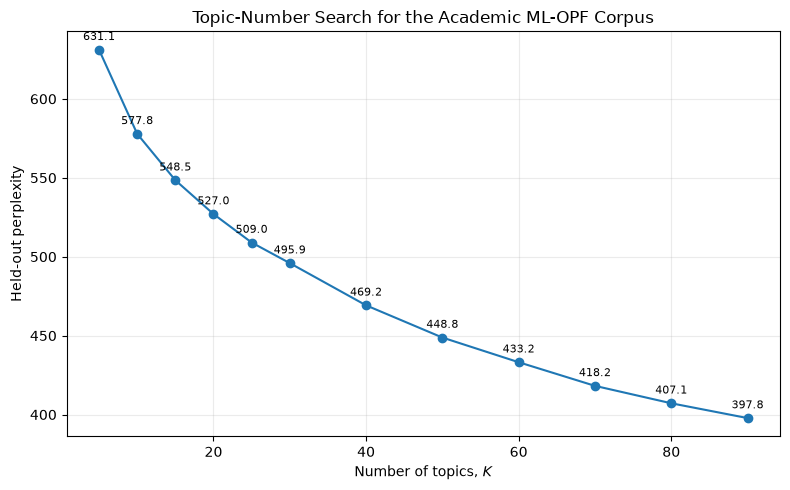

In [38]:
# ---------------------------------------------------------
# Plot complete K-search results
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.0, 5.0)
)


ax.plot(
    k_search_results["K"],
    k_search_results["Perplexity"],
    marker="o",
    linewidth=1.5,
)


for _, row in k_search_results.iterrows():

    ax.annotate(
        f"{row['Perplexity']:.1f}",
        (
            row["K"],
            row["Perplexity"],
        ),
        xytext=(
            0,
            7,
        ),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )


ax.set_xlabel(
    "Number of topics, $K$"
)

ax.set_ylabel(
    "Held-out perplexity"
)

ax.set_title(
    "Topic-Number Search for the Academic ML-OPF Corpus"
)

ax.grid(
    alpha=0.25
)


fig.tight_layout()


k_search_figure = (
    FIGURE_DIR
    / "scopus_academic_k_search.pdf"
)


fig.savefig(
    k_search_figure,
    format="pdf",
    bbox_inches="tight",
)


print(
    "Saved:",
    k_search_figure
)


plt.show()

Saved: m:\projects_latex\review_paper_2\output\scopus_research_landscape\figures\scopus_academic_k_marginal_improvement.pdf


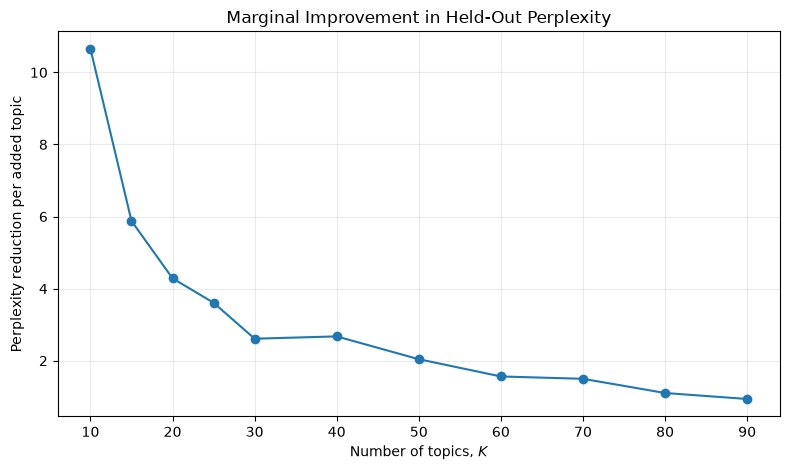

In [39]:
# ---------------------------------------------------------
# Plot marginal perplexity reduction
# ---------------------------------------------------------

marginal_data = (
    k_diagnostics
    .dropna(
        subset=[
            "Reduction_Per_Added_Topic"
        ]
    )
)


fig, ax = plt.subplots(
    figsize=(8.0, 4.8)
)


ax.plot(
    marginal_data["K"],
    marginal_data[
        "Reduction_Per_Added_Topic"
    ],
    marker="o",
    linewidth=1.5,
)


ax.set_xlabel(
    "Number of topics, $K$"
)

ax.set_ylabel(
    "Perplexity reduction per added topic"
)

ax.set_title(
    "Marginal Improvement in Held-Out Perplexity"
)

ax.grid(
    alpha=0.25
)


fig.tight_layout()


marginal_figure = (
    FIGURE_DIR
    / "scopus_academic_k_marginal_improvement.pdf"
)


fig.savefig(
    marginal_figure,
    format="pdf",
    bbox_inches="tight",
)


print(
    "Saved:",
    marginal_figure
)


plt.show()

### 3.6 Candidate Topic-Model Evaluation

The coarse and extended searches showed a monotonic decline in held-out
perplexity as the number of topics increased, but the marginal reduction
decreased progressively at larger values of $K$. Candidate models with
$K \in \{40, 50, 60, 70\}$ were therefore retained for more detailed
evaluation.

Because perplexity alone tends to favor increasingly complex topic models,
the candidate models are evaluated jointly using held-out perplexity,
semantic coherence, inter-topic similarity, and substantive interpretability.
The final topic number is selected by balancing predictive performance
against topic coherence, distinctiveness, and fragmentation.

In [40]:
# ---------------------------------------------------------
# Candidate topic numbers for detailed evaluation
# ---------------------------------------------------------

K_CANDIDATES = [
    40,
    50,
    60,
    70,
]


print("CANDIDATE TOPIC-MODEL EVALUATION")
print("=" * 50)

print(
    "Candidate K values:",
    K_CANDIDATES
)

CANDIDATE TOPIC-MODEL EVALUATION
Candidate K values: [40, 50, 60, 70]


In [41]:
# ---------------------------------------------------------
# Candidate-evaluation configuration
# ---------------------------------------------------------

TOP_N = 10

CANDIDATE_RANDOM_SEED = 123

CANDIDATE_BURN_IN = 500

CANDIDATE_ITERATIONS = 2000

CANDIDATE_THIN = 50


print("CANDIDATE MODEL CONFIGURATION")
print("=" * 50)

print(
    "K values       :",
    K_CANDIDATES
)

print(
    "Top terms      :",
    TOP_N
)

print(
    "Random seed    :",
    CANDIDATE_RANDOM_SEED
)

print(
    "Burn-in        :",
    CANDIDATE_BURN_IN
)

print(
    "Iterations     :",
    CANDIDATE_ITERATIONS
)

print(
    "Thinning       :",
    CANDIDATE_THIN
)

print(
    "Minimum DF     :",
    FINAL_MIN_DOC_FREQ
)

CANDIDATE MODEL CONFIGURATION
K values       : [40, 50, 60, 70]
Top terms      : 10
Random seed    : 123
Burn-in        : 500
Iterations     : 2000
Thinning       : 50
Minimum DF     : 83


#### 3.6.1 Candidate-Model Diagnostics

The retained candidate models are re-estimated using a longer Gibbs-sampling
configuration than that used during the coarse screening stage. Each model
is evaluated using four complementary criteria.

First, held-out perplexity measures predictive performance on documents not
used for model estimation. Second, semantic coherence evaluates the extent
to which the highest-probability terms within each topic co-occur across
training documents. Third, pairwise cosine similarity between topic-term
distributions is used to assess topic distinctiveness and potential
redundancy. Finally, the highest-probability terms of each topic are retained
for substantive interpretation.

The candidate models therefore provide a basis for selecting a topic number
that balances predictive performance, semantic coherence, topic
distinctiveness, and interpretability rather than minimizing perplexity
alone.

In [42]:
# ---------------------------------------------------------
# Candidate-evaluation output files
# ---------------------------------------------------------

candidate_summary_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_candidate_evaluation.csv"
)

candidate_topic_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_candidate_topic_diagnostics.csv"
)

candidate_top_terms_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_candidate_top_terms.csv"
)


print("CANDIDATE-EVALUATION OUTPUTS")
print("=" * 55)

print(
    "Summary          :",
    candidate_summary_file
)

print(
    "Topic diagnostics:",
    candidate_topic_file
)

print(
    "Top terms        :",
    candidate_top_terms_file
)

CANDIDATE-EVALUATION OUTPUTS
Summary          : m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_candidate_evaluation.csv
Topic diagnostics: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_candidate_topic_diagnostics.csv
Top terms        : m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_candidate_top_terms.csv


In [43]:
# ---------------------------------------------------------
# Load candidate-model evaluation computed on ISS
# ---------------------------------------------------------

candidate_summary_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_candidate_evaluation.csv"
)

candidate_topic_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_candidate_topic_diagnostics.csv"
)

candidate_top_terms_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_candidate_top_terms.csv"
)


for file_path in [
    candidate_summary_file,
    candidate_topic_file,
    candidate_top_terms_file,
]:

    if not file_path.exists():

        raise FileNotFoundError(
            f"Candidate result not found:\n"
            f"{file_path}"
        )


candidate_results = pd.read_csv(
    candidate_summary_file
)

candidate_topic_diagnostics = pd.read_csv(
    candidate_topic_file
)

candidate_top_terms = pd.read_csv(
    candidate_top_terms_file
)


candidate_results = (
    candidate_results
    .sort_values("K")
    .reset_index(drop=True)
)


print("SCOPUS ACADEMIC CANDIDATE MODEL EVALUATION")
print("=" * 60)

print(
    "K values:",
    candidate_results["K"].tolist()
)

print()

display(
    candidate_results
)

SCOPUS ACADEMIC CANDIDATE MODEL EVALUATION
K values: [40, 50, 60, 70]



,K,Perplexity,Mean_Coherence,Median_Coherence,Min_Coherence,Max_Coherence,SD_Coherence,Mean_Similarity,Median_Similarity,Max_Similarity,SD_Similarity,Elapsed_seconds,Training_documents,Heldout_documents,Vocabulary,Empty_training_removed,Empty_heldout_removed
0,40,468.868740,-71.330138,-72.667061,-96.648011,-44.078374,13.591904,0.045034,0.021028,0.698906,0.073643,235.059397,13127,3282,1842,0,0
1,50,448.467653,-74.318630,-74.329750,-103.534857,-44.479852,14.832359,0.039664,0.016757,0.641771,0.066357,266.679940,13127,3282,1842,0,0
2,60,432.536444,-75.440995,-76.253914,-109.823625,-42.302263,15.941083,0.034498,0.014634,0.785249,0.062503,309.746500,13127,3282,1842,0,0
3,70,418.141324,-77.178313,-77.475994,-124.099925,-43.313757,18.270901,0.033162,0.011637,0.868209,0.060812,343.041322,13127,3282,1842,0,0


In [44]:
display(
    candidate_results[
        [
            "K",
            "Perplexity",
            "Mean_Coherence",
            "Median_Coherence",
            "Min_Coherence",
            "Mean_Similarity",
            "Median_Similarity",
            "Max_Similarity",
        ]
    ]
)

,K,Perplexity,Mean_Coherence,Median_Coherence,Min_Coherence,Mean_Similarity,Median_Similarity,Max_Similarity
0,40,468.868740,-71.330138,-72.667061,-96.648011,0.045034,0.021028,0.698906
1,50,448.467653,-74.318630,-74.329750,-103.534857,0.039664,0.016757,0.641771
2,60,432.536444,-75.440995,-76.253914,-109.823625,0.034498,0.014634,0.785249
3,70,418.141324,-77.178313,-77.475994,-124.099925,0.033162,0.011637,0.868209


In [45]:
# ---------------------------------------------------------
# Candidate-model comparison
# ---------------------------------------------------------

candidate_comparison = (
    candidate_results[
        [
            "K",
            "Perplexity",
            "Mean_Coherence",
            "Median_Coherence",
            "Min_Coherence",
            "Mean_Similarity",
            "Median_Similarity",
            "Max_Similarity",
        ]
    ]
    .copy()
)


candidate_comparison[
    "Perplexity"
] = (
    candidate_comparison[
        "Perplexity"
    ]
    .round(2)
)


for column in [
    "Mean_Coherence",
    "Median_Coherence",
    "Min_Coherence",
]:

    candidate_comparison[
        column
    ] = (
        candidate_comparison[
            column
        ]
        .round(2)
    )


for column in [
    "Mean_Similarity",
    "Median_Similarity",
    "Max_Similarity",
]:

    candidate_comparison[
        column
    ] = (
        candidate_comparison[
            column
        ]
        .round(4)
    )


display(
    candidate_comparison
)

,K,Perplexity,Mean_Coherence,Median_Coherence,Min_Coherence,Mean_Similarity,Median_Similarity,Max_Similarity
0,40,468.87,-71.33,-72.67,-96.65,0.0450,0.0210,0.6989
1,50,448.47,-74.32,-74.33,-103.53,0.0397,0.0168,0.6418
2,60,432.54,-75.44,-76.25,-109.82,0.0345,0.0146,0.7852
3,70,418.14,-77.18,-77.48,-124.10,0.0332,0.0116,0.8682


In [46]:
# ---------------------------------------------------------
# Topic-level coherence distribution by candidate K
# ---------------------------------------------------------

coherence_distribution = (
    candidate_topic_diagnostics
    .groupby(
        "K"
    )["Coherence"]
    .agg(
        Topic_Count="count",
        Mean="mean",
        Median="median",
        SD="std",
        Minimum="min",
        Q10=lambda x: x.quantile(0.10),
        Q25=lambda x: x.quantile(0.25),
        Q75=lambda x: x.quantile(0.75),
        Maximum="max",
    )
    .reset_index()
)


display(
    coherence_distribution
)

,K,Topic_Count,Mean,Median,SD,Minimum,Q10,Q25,Q75,Maximum
0,40,40,-71.330138,-72.667061,13.591904,-96.648011,-85.931899,-82.538062,-60.543558,-44.078374
1,50,50,-74.318630,-74.329750,14.832359,-103.534857,-95.094115,-84.492754,-63.729864,-44.479852
2,60,60,-75.440995,-76.253914,15.941083,-109.823625,-94.971054,-86.081573,-65.308747,-42.302263
3,70,70,-77.178313,-77.475994,18.270901,-124.099925,-101.830614,-88.264775,-63.656742,-43.313757


Saved: m:\projects_latex\review_paper_2\output\scopus_research_landscape\figures\scopus_academic_candidate_coherence.pdf


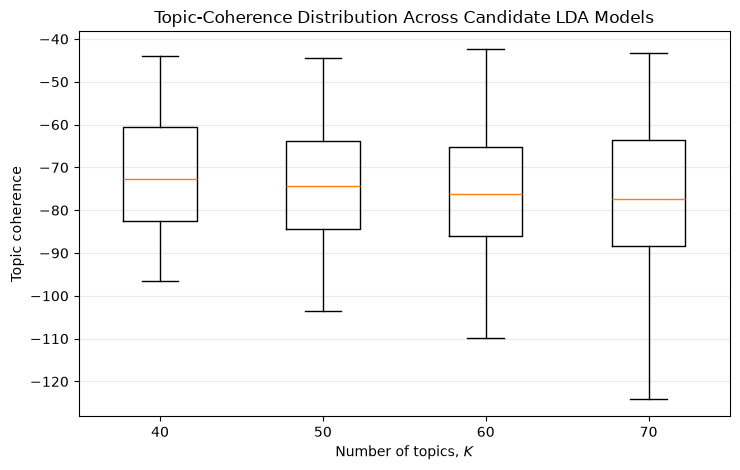

In [47]:
# ---------------------------------------------------------
# Candidate topic-coherence distributions
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)


coherence_groups = [
    candidate_topic_diagnostics.loc[
        candidate_topic_diagnostics["K"] == k,
        "Coherence",
    ].values
    for k in K_CANDIDATES
]


ax.boxplot(
    coherence_groups,
    tick_labels=[
        str(k)
        for k in K_CANDIDATES
    ],
)


ax.set_xlabel(
    "Number of topics, $K$"
)

ax.set_ylabel(
    "Topic coherence"
)

ax.set_title(
    "Topic-Coherence Distribution Across Candidate LDA Models"
)

ax.grid(
    axis="y",
    alpha=0.25,
)


fig.tight_layout()


coherence_figure = (
    FIGURE_DIR
    / "scopus_academic_candidate_coherence.pdf"
)


fig.savefig(
    coherence_figure,
    format="pdf",
    bbox_inches="tight",
)


print(
    "Saved:",
    coherence_figure
)


plt.show()

In [48]:
# ---------------------------------------------------------
# Compact top-term representation
# ---------------------------------------------------------

topic_term_summary = (
    candidate_top_terms
    .sort_values(
        [
            "K",
            "Topic",
            "Rank",
        ]
    )
    .groupby(
        [
            "K",
            "Topic",
        ]
    )["Term"]
    .apply(
        lambda terms:
            ", ".join(
                terms.astype(str)
            )
    )
    .reset_index(
        name="Top_Terms"
    )
)


topic_term_summary = (
    topic_term_summary
    .merge(
        candidate_topic_diagnostics[
            [
                "K",
                "Topic",
                "Coherence",
            ]
        ],
        on=[
            "K",
            "Topic",
        ],
        how="left",
    )
)


display(
    topic_term_summary.head(20)
)

,K,Topic,Top_Terms,Coherence
0,40,1,"control, frequenc, convert, system, stabil, pe...",-83.382802
1,40,2,"framework, enhanc, demonstr, integr, robust, a...",-62.614184
2,40,3,"featur, select, accuraci, use, classif, datase...",-77.023378
3,40,4,"grid, smart, resili, attack, detect, secur, fa...",-75.657313
4,40,5,"algorithm, hybrid, optim, swarm, particl, pso,...",-56.452147
5,40,6,"system, stabil, transmiss, ieee, line, bus, se...",-78.726568
6,40,7,"intellig, data, artifici, process, monitor, te...",-96.648011
7,40,8,"techniqu, natur, use, author, springer, part, ...",-73.548962
8,40,9,"use, time, result, test, valu, show, compar, o...",-53.377892
9,40,10,"uncertainti, generat, dispatch, schedul, unit,...",-72.440203


In [49]:
def show_candidate_topics(k):

    result = (
        topic_term_summary[
            topic_term_summary[
                "K"
            ] == k
        ]
        .sort_values(
            "Coherence",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

    print(
        f"K = {k}"
    )

    print(
        "=" * 60
    )

    display(
        result
    )

In [50]:
show_candidate_topics(
    60
)

K = 60


,K,Topic,Top_Terms,Coherence
0,60,1,"schedul, dispatch, oper, cost, econom, unit, g...",-42.302263
1,60,40,"algorithm, swarm, optim, particl, pso, metaheu...",-45.064357
2,60,19,"review, research, futur, comprehens, technolog...",-46.863008
3,60,30,"estim, state, measur, paramet, method, identif...",-49.403461
4,60,29,"techniqu, intellig, artifici, cluster, use, de...",-49.604320
5,60,25,"approach, propos, novel, effect, result, test,...",-49.764751
6,60,50,"dynam, adapt, strategi, improv, enhanc, effici...",-51.132694
7,60,54,"method, propos, base, calcul, result, paper, t...",-54.007780
8,60,7,"algorithm, genet, base, evolutionari, differen...",-54.735677
9,60,11,"enhanc, effici, advanc, potenti, signific, add...",-59.598123


### 3.7 Interpretation of the Selected Academic Topic Model

#### 3.7.1 Final LDA Model Estimation

The selected $K=50$ specification is re-estimated using the complete
preprocessed academic corpus to obtain the final topic-term and
document-topic posterior distributions. The topic-term distribution is used
to identify the highest-probability terms associated with each latent topic,
whereas the document-topic distribution is used to quantify topic prevalence
and identify representative scholarly publications.

Unlike the candidate-model evaluation, which uses the fixed training and
held-out subsets for model selection, the final model is estimated using all
documents retained in the academic corpus after preprocessing. This allows
the thematic characterization to use the full available academic evidence
after the model specification has been selected.

In [51]:
# ---------------------------------------------------------
# Final academic LDA configuration
# ---------------------------------------------------------

FINAL_K = 50

FINAL_RANDOM_SEED = 123

FINAL_BURN_IN = 500

FINAL_ITERATIONS = 2000

FINAL_THIN = 50

FINAL_TOP_N = 10

FINAL_REPRESENTATIVE_DOCUMENTS = 5


print("FINAL ACADEMIC LDA CONFIGURATION")
print("=" * 50)

print(
    "Number of topics        :",
    FINAL_K
)

print(
    "Minimum DF              :",
    FINAL_MIN_DOC_FREQ
)

print(
    "Random seed             :",
    FINAL_RANDOM_SEED
)

print(
    "Burn-in                 :",
    FINAL_BURN_IN
)

print(
    "Iterations              :",
    FINAL_ITERATIONS
)

print(
    "Thinning                :",
    FINAL_THIN
)

print(
    "Top terms per topic     :",
    FINAL_TOP_N
)

print(
    "Representative documents:",
    FINAL_REPRESENTATIVE_DOCUMENTS
)

FINAL ACADEMIC LDA CONFIGURATION
Number of topics        : 50
Minimum DF              : 83
Random seed             : 123
Burn-in                 : 500
Iterations              : 2000
Thinning                : 50
Top terms per topic     : 10
Representative documents: 5


In [52]:
# ---------------------------------------------------------
# Final academic LDA output files
# ---------------------------------------------------------

final_model_summary_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_model_summary.csv"
)

final_top_terms_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_top_terms.csv"
)

final_theta_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_document_topics.csv"
)

final_prevalence_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_topic_prevalence.csv"
)

final_representative_documents_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_representative_documents.csv"
)


print("FINAL ACADEMIC LDA OUTPUTS")
print("=" * 50)

print(
    "Model summary           :",
    final_model_summary_file
)

print(
    "Top terms               :",
    final_top_terms_file
)

print(
    "Document-topic posterior:",
    final_theta_file
)

print(
    "Topic prevalence        :",
    final_prevalence_file
)

print(
    "Representative documents:",
    final_representative_documents_file
)

FINAL ACADEMIC LDA OUTPUTS
Model summary           : m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_final_model_summary.csv
Top terms               : m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_final_top_terms.csv
Document-topic posterior: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_final_document_topics.csv
Topic prevalence        : m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_final_topic_prevalence.csv
Representative documents: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_final_representative_documents.csv


#### 3.7.2 Topic Interpretation and Prevalence

The selected $K=50$ model is interpreted using three complementary sources
of information: the highest-probability terms associated with each topic,
the scholarly publications receiving the highest posterior probability for
that topic, and the probability-weighted prevalence of the topic across the
academic corpus.

Topic prevalence is calculated from the document-topic posterior
distribution rather than from hard document assignments. For topic $k$,
prevalence is defined as

$$
\pi_k =
\frac{1}{D}
\sum_{d=1}^{D}
\theta_{dk},
$$

where $\theta_{dk}$ denotes the posterior probability of topic $k$ in
document $d$ and $D$ is the number of documents. This formulation preserves
the mixed-membership structure of LDA, allowing each scholarly publication
to contribute to multiple topics.

In [53]:
# ---------------------------------------------------------
# Load final academic LDA outputs
# ---------------------------------------------------------

final_summary_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_model_summary.csv"
)

final_top_terms_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_top_terms.csv"
)

final_theta_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_document_topics.csv"
)

final_prevalence_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_topic_prevalence.csv"
)

final_representative_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_representative_documents.csv"
)


final_model_summary = pd.read_csv(
    final_summary_file
)

final_top_terms = pd.read_csv(
    final_top_terms_file
)

final_theta = pd.read_csv(
    final_theta_file
)

final_topic_prevalence = pd.read_csv(
    final_prevalence_file
)

final_representative_documents = pd.read_csv(
    final_representative_file
)


print("FINAL ACADEMIC LDA OUTPUTS")
print("=" * 50)

print(
    "Topics                  :",
    final_top_terms["Topic"].nunique()
)

print(
    "Documents in theta      :",
    f"{len(final_theta):,}"
)

print(
    "Top-term rows           :",
    f"{len(final_top_terms):,}"
)

print(
    "Representative documents:",
    f"{len(final_representative_documents):,}"
)

print(
    "Prevalence sum          :",
    f"{final_topic_prevalence['Prevalence_Percent'].sum():.6f}%"
)

print()

display(
    final_model_summary
)

FINAL ACADEMIC LDA OUTPUTS
Topics                  : 50
Documents in theta      : 16,409
Top-term rows           : 500
Representative documents: 250
Prevalence sum          : 100.000000%



,K,Documents,Vocabulary,Minimum_DF,Empty_Documents_Removed,Random_Seed,Burn_In,Iterations,Thin,Top_N,Representative_N,Theta_Max_RowSum_Error,Beta_Max_RowSum_Error,Topic_Prevalence_Sum,Elapsed_seconds
0,50,16409,1842,83,0,123,500,2000,50,10,5,1.110223e-16,2.220446e-16,1,313.174458


In [54]:
# ---------------------------------------------------------
# Construct final topic interpretation table
# ---------------------------------------------------------

final_topic_terms = (
    final_top_terms
    .sort_values(
        [
            "Topic",
            "Rank",
        ]
    )
    .groupby(
        "Topic"
    )["Term"]
    .apply(
        lambda terms:
            ", ".join(
                terms.astype(str)
            )
    )
    .reset_index(
        name="Top_Terms"
    )
)


final_topic_interpretation = (
    final_topic_prevalence
    .merge(
        final_topic_terms,
        on="Topic",
        how="left",
    )
    .sort_values(
        "Prevalence_Rank"
    )
    .reset_index(
        drop=True
    )
)


display(
    final_topic_interpretation[
        [
            "Topic",
            "Prevalence_Rank",
            "Prevalence_Percent",
            "Top_Terms",
        ]
    ]
)

,Topic,Prevalence_Rank,Prevalence_Percent,Top_Terms
0,6,1,2.612828,"algorithm, search, converg, local, explor, ben..."
1,15,2,2.497789,"review, research, applic, futur, comprehens, d..."
2,48,3,2.336094,"energi, renew, storag, system, sourc, manag, i..."
3,9,4,2.243603,"constraint, program, linear, problem, feasibl,..."
4,25,5,2.177535,"intellig, technolog, advanc, artifici, integr,..."
5,2,6,2.164576,"algorithm, swarm, particl, pso, genet, metaheu..."
6,19,7,2.153735,"control, system, stabil, frequenc, regul, tran..."
7,42,8,2.134677,"voltag, loss, system, reactiv, stabil, devic, ..."
8,44,9,2.120591,"problem, solv, solut, algorithm, formul, find,..."
9,28,10,2.086236,"featur, select, cluster, classif, accuraci, da..."


In [55]:
# ---------------------------------------------------------
# Representative publication titles by topic
# ---------------------------------------------------------

representative_titles = (
    final_representative_documents
    .sort_values(
        [
            "Topic",
            "Rank",
        ]
    )
    .groupby(
        "Topic"
    )["Title"]
    .apply(
        lambda titles:
            " | ".join(
                titles.astype(str)
            )
    )
    .reset_index(
        name="Representative_Titles"
    )
)


final_topic_interpretation = (
    final_topic_interpretation
    .merge(
        representative_titles,
        on="Topic",
        how="left",
    )
)


display(
    final_topic_interpretation[
        [
            "Topic",
            "Prevalence_Rank",
            "Prevalence_Percent",
            "Top_Terms",
            "Representative_Titles",
        ]
    ]
)

,Topic,Prevalence_Rank,Prevalence_Percent,Top_Terms,Representative_Titles
0,6,1,2.612828,"algorithm, search, converg, local, explor, ben...",Harris Hawk optimization algorithm based on im...
1,15,2,2.497789,"review, research, applic, futur, comprehens, d...",Advances in the modeling of multiphase flows a...
2,48,3,2.336094,"energi, renew, storag, system, sourc, manag, i...",Intelligent Energy Management Systems in Hybri...
3,9,4,2.243603,"constraint, program, linear, problem, feasibl,...",Exact augmented Lagrangian duality for mixed i...
4,25,5,2.177535,"intellig, technolog, advanc, artifici, integr,...",Digital twin technology and AI implementations...
5,2,6,2.164576,"algorithm, swarm, particl, pso, genet, metaheu...",Application of artificial bee colony algorithm...
6,19,7,2.153735,"control, system, stabil, frequenc, regul, tran...",Load Frequency Control of an Interconnected Po...
7,42,8,2.134677,"voltag, loss, system, reactiv, stabil, devic, ...",Voltage stability enhancement through optimal ...
8,44,9,2.120591,"problem, solv, solut, algorithm, formul, find,...",A general system for heuristic minimization of...
9,28,10,2.086236,"featur, select, cluster, classif, accuraci, da...",Optimized Improved Random Forest-Fostered Glau...


In [56]:
# ---------------------------------------------------------
# Build topic-labeling worksheet
# ---------------------------------------------------------

topic_labeling_table = (
    final_topic_interpretation[
        [
            "Topic",
            "Prevalence_Rank",
            "Prevalence_Percent",
            "Top_Terms",
            "Representative_Titles",
        ]
    ]
    .copy()
)


# Empty columns for substantive coding
topic_labeling_table[
    "Topic_Label"
] = ""

topic_labeling_table[
    "Macro_Theme"
] = ""


topic_labeling_table = (
    topic_labeling_table
    .sort_values(
        "Prevalence_Rank"
    )
    .reset_index(
        drop=True
    )
)


display(
    topic_labeling_table
)

,Topic,Prevalence_Rank,Prevalence_Percent,Top_Terms,Representative_Titles,Topic_Label,Macro_Theme
0,6,1,2.612828,"algorithm, search, converg, local, explor, ben...",Harris Hawk optimization algorithm based on im...,,
1,15,2,2.497789,"review, research, applic, futur, comprehens, d...",Advances in the modeling of multiphase flows a...,,
2,48,3,2.336094,"energi, renew, storag, system, sourc, manag, i...",Intelligent Energy Management Systems in Hybri...,,
3,9,4,2.243603,"constraint, program, linear, problem, feasibl,...",Exact augmented Lagrangian duality for mixed i...,,
4,25,5,2.177535,"intellig, technolog, advanc, artifici, integr,...",Digital twin technology and AI implementations...,,
5,2,6,2.164576,"algorithm, swarm, particl, pso, genet, metaheu...",Application of artificial bee colony algorithm...,,
6,19,7,2.153735,"control, system, stabil, frequenc, regul, tran...",Load Frequency Control of an Interconnected Po...,,
7,42,8,2.134677,"voltag, loss, system, reactiv, stabil, devic, ...",Voltage stability enhancement through optimal ...,,
8,44,9,2.120591,"problem, solv, solut, algorithm, formul, find,...",A general system for heuristic minimization of...,,
9,28,10,2.086236,"featur, select, cluster, classif, accuraci, da...",Optimized Improved Random Forest-Fostered Glau...,,


In [57]:
topic_labeling_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_topic_labeling.csv"
)


topic_labeling_table.to_csv(
    topic_labeling_file,
    index=False,
)


print(
    "Saved:",
    topic_labeling_file
)

Saved: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_topic_labeling.csv


In [58]:
# ---------------------------------------------------------
# Topic interpretation report
# ---------------------------------------------------------

for topic_row in (
    final_topic_interpretation
    .sort_values("Prevalence_Rank")
    .itertuples()
):

    topic = topic_row.Topic

    print("=" * 90)

    print(
        f"TOPIC {topic} "
        f"| Rank {topic_row.Prevalence_Rank} "
        f"| Prevalence {topic_row.Prevalence_Percent:.2f}%"
    )

    print("-" * 90)

    print(
        "Top terms:"
    )

    print(
        topic_row.Top_Terms
    )

    print()

    print(
        "Representative publications:"
    )


    representative_subset = (
        final_representative_documents[
            final_representative_documents[
                "Topic"
            ] == topic
        ]
        .sort_values("Rank")
    )


    for row in representative_subset.itertuples():

        print(
            f"  {row.Rank}. "
            f"{row.Title}"
        )

    print()

TOPIC 6 | Rank 1 | Prevalence 2.61%
------------------------------------------------------------------------------------------
Top terms:
algorithm, search, converg, local, explor, benchmark, function, global, exploit, test

Representative publications:
  1. Harris Hawk optimization algorithm based on improved escaping energy factors and random searching strategies
  2. Laplace crossover and random replacement strategy boosted Harris hawks optimization: performance optimization and analysis
  3. IHHO: an improved Harris Hawks optimization algorithm for solving engineering problems
  4. A chaotic arithmetic optimization algorithm with Cauchy perturbation and differential evolution for engineering design problems
  5. A Novel Brownian Motion-based Hybrid Whale Optimization Algorithm

TOPIC 15 | Rank 2 | Prevalence 2.50%
------------------------------------------------------------------------------------------
Top terms:
review, research, applic, futur, comprehens, discuss, paper, provid,

In [59]:
# ---------------------------------------------------------
# Aggregate latent topics into macro-themes
# ---------------------------------------------------------

macro_theme_summary = (
    topic_labeling_table
    .groupby(
        "Macro_Theme",
        as_index=False,
    )
    .agg(
        Prevalence_Percent=(
            "Prevalence_Percent",
            "sum",
        ),
        Number_of_Topics=(
            "Topic",
            "count",
        ),
        LDA_Topics=(
            "Topic",
            lambda x:
                ", ".join(
                    map(
                        str,
                        sorted(x),
                    )
                ),
        ),
        Topic_Labels=(
            "Topic_Label",
            lambda x:
                "; ".join(x),
        ),
    )
    .sort_values(
        "Prevalence_Percent",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


macro_theme_summary[
    "Rank"
] = (
    np.arange(
        1,
        len(macro_theme_summary) + 1,
    )
)


display(
    macro_theme_summary
)

,Macro_Theme,Prevalence_Percent,Number_of_Topics,LDA_Topics,Topic_Labels,Rank
0,,100.0,50,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,...",; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ; ...,1


#### 3.7.3 Topic Labeling and Macro-Theme Consolidation

The 50 latent topics provide a fine-grained representation of the vocabulary
and research problems contained in the academic corpus. For substantive
interpretation, each topic is assigned a descriptive label based jointly on
its highest-probability terms and representative publications. Related latent
topics are subsequently consolidated into broader macro-themes.

This two-level representation separates statistical topic resolution from
the thematic resolution used for reporting. The original LDA topics are
retained for reproducibility, while the macro-themes provide a more concise
representation of the principal methodological and application-oriented
directions in the academic ML--OPF literature.

In [60]:
# ---------------------------------------------------------
# Manual interpretation of the 50 latent topics
# ---------------------------------------------------------

topic_labels = {

    1:  "Smart grids and microgrid operation",
    2:  "Swarm and evolutionary optimization",
    3:  "Optimization and computational-method surveys",
    4:  "Active distribution network operation",
    5:  "Engineering design and surrogate optimization",
    6:  "Metaheuristic search algorithms",
    7:  "Hybrid metaheuristic optimization",
    8:  "Transmission protection and fault diagnosis",
    9:  "Mathematical and convex optimization",
    10: "Electricity markets and energy trading",

    11: "Thermal and energy-system modeling",
    12: "Deep reinforcement learning for control",
    13: "Advanced computational and optimization methods",
    14: "Physics-informed and multimodal learning",
    15: "Reviews and integrated energy-system research",
    16: "Real-time and security-oriented optimization",
    17: "Learning and optimization for optimal power flow",
    18: "Power electronic converters",
    19: "Frequency control and dynamic stability",
    20: "Emerging grid operation and monitoring",

    21: "Electric vehicles and smart charging",
    22: "Data-driven modern power-system operation",
    23: "Neural networks and graph learning",
    24: "Multi-objective optimization",
    25: "AI, digital twins, and emerging technologies",
    26: "Demand response and load management",
    27: "Renewable generation forecasting",
    28: "Feature selection and classification",
    29: "Sensitivity and performance analysis",
    30: "Metaheuristic foundations and reviews",

    31: "Power quality and system-performance enhancement",
    32: "IoT and intelligent sensing",
    33: "Adaptive and real-time energy management",
    34: "Machine-learning prediction and regression",
    35: "Power-system planning and capacity expansion",
    36: "Predictive-model performance and error analysis",
    37: "Cybersecurity and false-data attack detection",
    38: "Power-flow and computational solution methods",
    39: "High-performance and surrogate computing",
    40: "Robust and stochastic optimization",

    41: "Low-carbon and sustainable energy systems",
    42: "Voltage stability and reactive-power optimization",
    43: "Multi-stage and hybrid optimization",
    44: "General heuristic optimization",
    45: "Optimization applications and engineering methods",
    46: "Power-system reliability and resilience",
    47: "Unit commitment and economic dispatch",
    48: "Renewable energy and storage management",
    49: "Distributed and decentralized optimization",
    50: "State estimation and parameter identification",
}

In [61]:
# ---------------------------------------------------------
# Consolidate latent topics into academic macro-themes
# ---------------------------------------------------------

topic_macro_themes = {

    # 1. Optimization algorithms and metaheuristics
    2:  "Optimization Algorithms and Metaheuristics",
    3:  "Optimization Algorithms and Metaheuristics",
    6:  "Optimization Algorithms and Metaheuristics",
    7:  "Optimization Algorithms and Metaheuristics",
    13: "Optimization Algorithms and Metaheuristics",
    24: "Optimization Algorithms and Metaheuristics",
    30: "Optimization Algorithms and Metaheuristics",
    43: "Optimization Algorithms and Metaheuristics",
    44: "Optimization Algorithms and Metaheuristics",
    45: "Optimization Algorithms and Metaheuristics",

    # 2. Mathematical, distributed, and uncertainty-aware optimization
    9:  "Mathematical and Distributed Optimization",
    40: "Mathematical and Distributed Optimization",
    49: "Mathematical and Distributed Optimization",

    # 3. Machine learning and data-driven methods
    14: "Machine Learning and Data-Driven Methods",
    23: "Machine Learning and Data-Driven Methods",
    25: "Machine Learning and Data-Driven Methods",
    28: "Machine Learning and Data-Driven Methods",
    29: "Machine Learning and Data-Driven Methods",
    32: "Machine Learning and Data-Driven Methods",
    34: "Machine Learning and Data-Driven Methods",
    36: "Machine Learning and Data-Driven Methods",
    39: "Machine Learning and Data-Driven Methods",

    # 4. OPF, power flow, and grid optimization
    4:  "OPF and Grid Optimization",
    17: "OPF and Grid Optimization",
    38: "OPF and Grid Optimization",
    42: "OPF and Grid Optimization",

    # 5. Power-system control, stability, and power quality
    19: "Control, Stability, and Power Quality",
    31: "Control, Stability, and Power Quality",
    33: "Control, Stability, and Power Quality",

    # 6. Energy management, renewables, and storage
    1:  "Energy Management, Renewables, and Storage",
    11: "Energy Management, Renewables, and Storage",
    15: "Energy Management, Renewables, and Storage",
    27: "Energy Management, Renewables, and Storage",
    41: "Energy Management, Renewables, and Storage",
    48: "Energy Management, Renewables, and Storage",

    # 7. Markets, scheduling, demand response, and planning
    10: "Markets, Scheduling, and Planning",
    26: "Markets, Scheduling, and Planning",
    35: "Markets, Scheduling, and Planning",
    47: "Markets, Scheduling, and Planning",

    # 8. Reinforcement learning and intelligent control
    12: "Reinforcement Learning and Intelligent Control",
    20: "Reinforcement Learning and Intelligent Control",

    # 9. Reliability, security, protection, and state awareness
    8:  "Reliability, Security, and State Awareness",
    16: "Reliability, Security, and State Awareness",
    22: "Reliability, Security, and State Awareness",
    37: "Reliability, Security, and State Awareness",
    46: "Reliability, Security, and State Awareness",
    50: "Reliability, Security, and State Awareness",

    # 10. Electrification, power electronics, and flexible technologies
    5:  "Electrification and Enabling Technologies",
    18: "Electrification and Enabling Technologies",
    21: "Electrification and Enabling Technologies",
}

In [62]:
# ---------------------------------------------------------
# Validate topic coding
# ---------------------------------------------------------

expected_topics = set(
    range(
        1,
        FINAL_K + 1,
    )
)

labelled_topics = set(
    topic_labels.keys()
)

macro_assigned_topics = set(
    topic_macro_themes.keys()
)


assert labelled_topics == expected_topics, (
    "Topic-label mapping is incomplete."
)

assert macro_assigned_topics == expected_topics, (
    "Macro-theme mapping is incomplete."
)


print(
    "Topic labels assigned :",
    len(topic_labels)
)

print(
    "Macro themes assigned :",
    len(topic_macro_themes)
)

print(
    "Unique macro-themes   :",
    len(
        set(
            topic_macro_themes.values()
        )
    )
)

Topic labels assigned : 50
Macro themes assigned : 50
Unique macro-themes   : 10


In [63]:
# ---------------------------------------------------------
# Apply topic labels and macro-theme assignments
# ---------------------------------------------------------

topic_labeling_table[
    "Topic_Label"
] = (
    topic_labeling_table[
        "Topic"
    ]
    .map(
        topic_labels
    )
)


topic_labeling_table[
    "Macro_Theme"
] = (
    topic_labeling_table[
        "Topic"
    ]
    .map(
        topic_macro_themes
    )
)


if (
    topic_labeling_table[
        "Topic_Label"
    ]
    .isna()
    .any()
):

    raise ValueError(
        "Some topics do not have a topic label."
    )


if (
    topic_labeling_table[
        "Macro_Theme"
    ]
    .isna()
    .any()
):

    raise ValueError(
        "Some topics do not have a macro-theme."
    )


display(
    topic_labeling_table[
        [
            "Topic",
            "Prevalence_Rank",
            "Prevalence_Percent",
            "Topic_Label",
            "Macro_Theme",
            "Top_Terms",
        ]
    ]
)

,Topic,Prevalence_Rank,Prevalence_Percent,Topic_Label,Macro_Theme,Top_Terms
0,6,1,2.612828,Metaheuristic search algorithms,Optimization Algorithms and Metaheuristics,"algorithm, search, converg, local, explor, ben..."
1,15,2,2.497789,Reviews and integrated energy-system research,"Energy Management, Renewables, and Storage","review, research, applic, futur, comprehens, d..."
2,48,3,2.336094,Renewable energy and storage management,"Energy Management, Renewables, and Storage","energi, renew, storag, system, sourc, manag, i..."
3,9,4,2.243603,Mathematical and convex optimization,Mathematical and Distributed Optimization,"constraint, program, linear, problem, feasibl,..."
4,25,5,2.177535,"AI, digital twins, and emerging technologies",Machine Learning and Data-Driven Methods,"intellig, technolog, advanc, artifici, integr,..."
5,2,6,2.164576,Swarm and evolutionary optimization,Optimization Algorithms and Metaheuristics,"algorithm, swarm, particl, pso, genet, metaheu..."
6,19,7,2.153735,Frequency control and dynamic stability,"Control, Stability, and Power Quality","control, system, stabil, frequenc, regul, tran..."
7,42,8,2.134677,Voltage stability and reactive-power optimization,OPF and Grid Optimization,"voltag, loss, system, reactiv, stabil, devic, ..."
8,44,9,2.120591,General heuristic optimization,Optimization Algorithms and Metaheuristics,"problem, solv, solut, algorithm, formul, find,..."
9,28,10,2.086236,Feature selection and classification,Machine Learning and Data-Driven Methods,"featur, select, cluster, classif, accuraci, da..."


In [64]:
topic_labeling_table.to_csv(
    topic_labeling_file,
    index=False,
)


print(
    "Saved:",
    topic_labeling_file
)

Saved: m:\projects_latex\review_paper_2\output\scopus_research_landscape\lda\scopus_academic_topic_labeling.csv


In [65]:
# ---------------------------------------------------------
# Aggregate prevalence by macro-theme
# ---------------------------------------------------------

macro_theme_summary = (
    topic_labeling_table
    .groupby(
        "Macro_Theme",
        as_index=False,
    )
    .agg(
        Prevalence_Percent=(
            "Prevalence_Percent",
            "sum",
        ),
        Number_of_Topics=(
            "Topic",
            "count",
        ),
        LDA_Topics=(
            "Topic",
            lambda x:
                ", ".join(
                    map(
                        str,
                        sorted(x),
                    )
                ),
        ),
        Topic_Labels=(
            "Topic_Label",
            lambda x:
                "; ".join(x),
        ),
    )
    .sort_values(
        "Prevalence_Percent",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


macro_theme_summary.insert(
    0,
    "Rank",
    np.arange(
        1,
        len(macro_theme_summary) + 1,
    ),
)


macro_theme_summary[
    "Prevalence_Percent"
] = (
    macro_theme_summary[
        "Prevalence_Percent"
    ]
    .round(2)
)


display(
    macro_theme_summary
)

,Rank,Macro_Theme,Prevalence_Percent,Number_of_Topics,LDA_Topics,Topic_Labels
0,1,Optimization Algorithms and Metaheuristics,20.57,10,"2, 3, 6, 7, 13, 24, 30, 43, 44, 45",Metaheuristic search algorithms; Swarm and evo...
1,2,Machine Learning and Data-Driven Methods,17.98,9,"14, 23, 25, 28, 29, 32, 34, 36, 39","AI, digital twins, and emerging technologies; ..."
2,3,"Energy Management, Renewables, and Storage",12.34,6,"1, 11, 15, 27, 41, 48",Reviews and integrated energy-system research;...
3,4,"Reliability, Security, and State Awareness",11.30,6,"8, 16, 22, 37, 46, 50",Real-time and security-oriented optimization; ...
4,5,OPF and Grid Optimization,8.22,4,"4, 17, 38, 42",Voltage stability and reactive-power optimizat...
5,6,"Markets, Scheduling, and Planning",7.66,4,"10, 26, 35, 47",Unit commitment and economic dispatch; Electri...
6,7,Mathematical and Distributed Optimization,6.26,3,"9, 40, 49",Mathematical and convex optimization; Distribu...
7,8,"Control, Stability, and Power Quality",6.00,3,"19, 31, 33",Frequency control and dynamic stability; Power...
8,9,Electrification and Enabling Technologies,5.68,3,"5, 18, 21",Power electronic converters; Engineering desig...
9,10,Reinforcement Learning and Intelligent Control,4.00,2,"12, 20",Emerging grid operation and monitoring; Deep r...


In [66]:
print(
    "Number of macro-themes:",
    len(
        macro_theme_summary
    )
)

print(
    "Total prevalence:",
    f"{macro_theme_summary['Prevalence_Percent'].sum():.2f}%"
)

Number of macro-themes: 10
Total prevalence: 100.01%
